In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.catalog.accumulate import *
from compact.catalog.bin import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import os
import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

In [24]:
# define grids

r_perp = np.linspace(5, 140, 135+1)
r_los = np.linspace(5, 140, 135+1)

r_p = 0.5*(r_perp[1:]+r_perp[:-1])
r_l = 0.5*(r_los[1:]+r_los[:-1])


r_p_2d, r_l_2d = np.meshgrid(r_p, r_l, indexing='ij')
r = np.sqrt(r_p_2d**2 + r_l_2d**2)

mu = r_p_2d/r 

x = r * ( 1 - mu ) 
x2 = r - r_p

In [3]:
cosmo = cosmology.setCosmology('planck18')


box_length = 2000 #Mpc/h, AS box side length

m_p = 2e9 # h^-1 M_sun, particle mass

# massbins
log_edges = np.array([[12, 12.01], [12.5, 12.6], [13, 13.1], [13.5, 13.6], [14.0, 14.2], [14.4, 14.7]])
massbins = 10**log_edges

In [ ]:

# compile halo-halo pairs 
halo_path = f'/spiff/hengweichang/AbacusSummit_base/snapshots/AbacusSummit_base_c000_ph000/halos/z0.200/halo_combined.h5'

hsb_path = f'/spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/SBp/'

vel_path = f'/spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/pairwise_velocity_selections/'

os.makedirs(os.path.dirname(hsb_path), exist_ok=True)
os.makedirs(os.path.dirname(vel_path), exist_ok=True)

vel_path = vel_path+'halo_halo_pairs_no_vlos_cut_massbin_test_SB500.hdf5'

# split into subboxes
with h5.File(halo_path, 'r') as hdf:
    hcat = hdf['halos'][:]

    #
    hm_cut = m_p * hcat['N_total'][()] >= 1e13 #& (m_p * hcat['N_total'][()] <= massbins[k][1])

    hpos = np.array([
        hcat['x'][()][hm_cut],
        hcat['y'][()][hm_cut], 
        hcat['z'][()][hm_cut],
    ]).T 

    hvel = np.array([
        hcat['vx'][()][hm_cut],
        hcat['vy'][()][hm_cut], 
        hcat['vz'][()][hm_cut],
    ]).T

    hid = hcat['hid_cleaned'][()][hm_cut]
    #upid = hcat['PID'][()][hm_cut] #NOTE: no upid for CompaSO halos!!

    generate_sub_box_ids(hpos%box_length, box_length, box_length / 4, hid.shape[0] // 1000, hsb_path, name='halo')

    split_simulation_into_sub_boxes(
        positions=hpos%box_length, 
        velocities=hvel, 
        ids=hid, 
        upids=hid, #NOTE: just using hid's instead, should be fine?
        boxsize=box_length, 
        subsize=box_length / 4,
        chunksize=hid.shape[0] // 1000, 
        dtypes=[hpos[0].dtype, hvel[0].dtype], 
        path=hsb_path, 
        name='halo'
    )

print('Starting pair selection for all single bin...')
with h5.File(vel_path, 'w') as hdf:
    #for k in range(len(massbins)):

    k = 3 # mass bin index for test

    mcut = (m_p * hcat['N_total'][()] >= massbins[k][0]) & (m_p * hcat['N_total'][()] <= massbins[k][1])

    rel_r, rel_R, rel_rlos, vpeclos, rel_vr, rel_vt = get_pairwise_halo_pw_quants( len(hid), 
                                                                                                                140, 
                                                                                                                box_length, 
                                                                                                                box_length / 4, 
                                                                                                                halo_path, 
                                                                                                                hsb_path, 
                                                                                                                mass_mask=mcut,
                                                                                                                id_label='hid_cleaned',
                                                                                                                vmax_label='N_total', #NOTE: no vmax either; using N particles as analog for sorting.
                                                                                                                Abacus =True,
                                                                                                                n_jobs=84)  
    
    hdf.create_dataset(name=f'r', data=rel_r, dtype=np.float64) 
    hdf.create_dataset(name=f'R', data=rel_R, dtype=np.float64) 
    hdf.create_dataset(name=f'rlos', data=rel_rlos, dtype=np.float64) 
    hdf.create_dataset(name=f'vpeclos', data=vpeclos, dtype=np.float64) 
    hdf.create_dataset(name=f'vr', data=rel_vr, dtype=np.float64)
    hdf.create_dataset(name=f'vt', data=rel_vt, dtype=np.float64) 


# /{k}
# /{k}
# /{k}
# /{k}
# /{k}
# /{k}


Chunk: 100%|██████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6589.67it/s]


	● Elapsed time: 0:00:00.162242 generate_sub_box_ids


Chunk: 100%|████████████████████████████████████████████████████| 1000/1000 [00:40<00:00, 24.89it/s]


	● Elapsed time: 0:00:40.191470 split_simulation_into_sub_boxes
Starting pair selection for all mass bins...


Processing sub-box:   0%|                                                    | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

	● Elapsed time: 0:05:07.806375 get_pairwise_halo_pw_quants


In [4]:
len(rel_r)/280004525

4.5752492428470575

In [6]:
# define paths to selections, save

path = f'/spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/pairwise_velocity_selections/'+'halo_halo_pairs_no_vlos_cut_massbin_test_SB500.hdf5'

save_path = f'/spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/'

M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

binned_dict, master_df = bin_pairwise_cat(path, save_path, R_bins=r_perp, rlos_bins=r_los, M_bins=massbins[k])


Successfully saved binned data to: /spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/binned_M1_3.16e+13-3.98e+13_R135_5.0-140.0_rlos135_5.0-140.0.h5


In [30]:
# load saved binned data
path = f'/spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/pairwise_velocity_selections/'+'halo_halo_pairs_no_vlos_cut_massbin_test_SB500.hdf5'

save_path = f'/spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/'
# bin selections

# mass bins
log_edges = np.array([[12, 12.01], [12.5, 12.6], [13, 13.1], [13.5, 13.6], [14.0, 14.2], [14.4, 14.7]])
massbins = 10**log_edges

M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

binned_dict, master_df = load_pairwise_cat(save_path+'binned_M1_3.16e+13-3.98e+13_R135_5.0-140.0_rlos135_5.0-140.0.h5')

In [34]:
# compute mean radial velocity profile <v_r|r> for a single sim, single mass bin

data_df = master_df

data_df['r'] = np.sqrt(data_df['R']**2 + data_df['rlos']**2)
data_df['r_bin'] = pd.cut(data_df['r'], bins=r_perp, labels=False, include_lowest=True)

profile = (
    data_df.dropna(subset=['r_bin'])
    .groupby('r_bin')['vr']
    .mean()
)

mean_vr_r = profile.reindex(range(len(r_p))).values

mask = np.isfinite(mean_vr_r)
if mask.sum() < 4:  # need enough points for k=5 spline; adjust threshold if needed
    mean_vr_r_interp = None
else:
    mean_vr_r_interp = UnivariateSpline(r_p[mask], mean_vr_r[mask], s=0, k=5, ext=3)

In [4]:
box_length = 2_000

redshift = 0.2
a = 1/(1+redshift)

conv = a*cosmo.Hz(redshift)/cosmo.h * box_length
conv

np.float64(184585.0385567896)

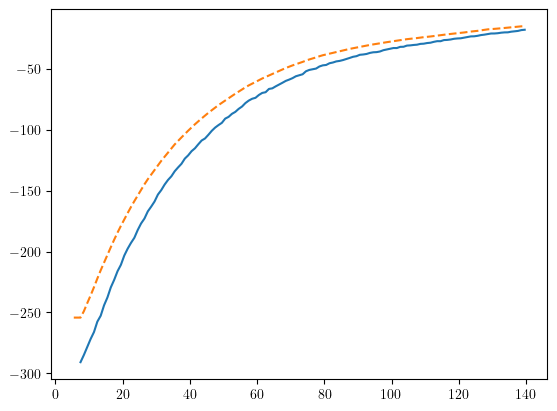

In [41]:
plt.plot(r_p, conv*mean_vr_r)
plt.plot(r_p, interps[3](r_p), ls='--')

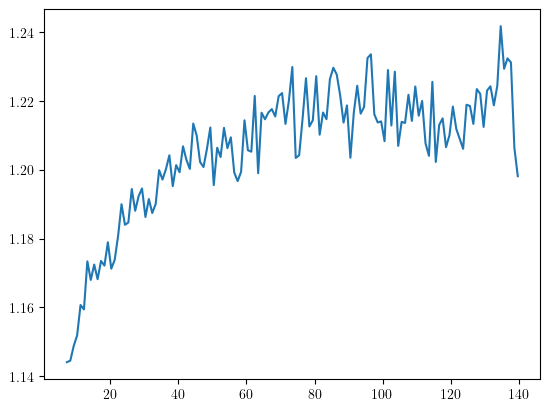

In [45]:
plt.plot(r_p, conv*mean_vr_r/interps[3](r_p))

In [11]:
# save 
#os.makedirs(os.path.dirname('/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/'), exist_ok=True)
save_path_vr = save_path+'mean_vr_r_single mass.hdf5'

with h5.File(save_path_vr, 'w') as hdf:
    hdf.create_dataset('mean_vr_r', data=mean_vr_r)
    #hdf.create_dataset('interps', data=mean_vr_r_m_sims_interps) 

    hdf.attrs['r_edges'] = r_perp
    hdf.attrs['M_edges'] = massbins
    hdf.attrs['M_index'] = k 

In [36]:
# fit skew-t to P(v_pec|R, rlos, M) to each sim

from scipy.optimize import curve_fit

nus = 6

ST_pars = np.full((len(r_p), len(r_l), 3), np.nan)
ST_errs = np.full(ST_pars.shape, np.nan)

data_dict = binned_dict

mean_vr_interp = mean_vr_r_interp

for j in range(len(r_p)):
    if j not in data_dict:
        continue

    for i in range(len(r_l)):
        if i not in data_dict[j]:
            continue

        r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
        theta = np.arctan2(r_l[i], r_p[j])
        sin = np.sin(theta)

        peak = conv*mean_vr_interp(r_3d) * sin

        width = np.std(conv*data_dict[j][i]['vpeclos'])

        ve = np.linspace(peak-2500, peak+2500, 50+1)
        vc = 0.5*(ve[1:] + ve[:-1])

        hist, edges = np.histogram(conv*data_dict[j][i]['vpeclos'], bins=ve, density=True)
        cent = 0.5*(edges[1:] + edges[:-1])

        if np.isnan(hist).any():
            continue

        try:
            p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                            cent, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
        except RuntimeError:
            continue
        
        ST_pars[j, i] = p
        ST_errs[j, i] = np.sqrt(np.diag(c))
            

In [12]:
# parallel version
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from tqdm import tqdm
from scipy.optimize import curve_fit

nus = 6

ST_pars = np.full((len(cosmo_nums), len(M_cens), len(r_p), len(r_l), 3), np.nan)
ST_errs = np.full(ST_pars.shape, np.nan)


def fit_sim_k(sim, k, data_dict, mean_vr_interp, r_p, r_l, nus):
    out = {}
    for j in range(len(r_p)):
        if j not in data_dict[k]:
            continue
        for i in range(len(r_l)):
            if i not in data_dict[k][j]:
                continue
            r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
            theta = np.arctan2(r_l[i], r_p[j])
            peak = mean_vr_interp(r_3d) * np.sin(theta)
            width = np.std(data_dict[k][j][i]['vpeclos'])

            ve = np.linspace(peak-2500, peak+2500, 51)
            vc = 0.5*(ve[1:] + ve[:-1])
            hist, edges = np.histogram(data_dict[k][j][i]['vpeclos'], bins=ve, density=True)

            if np.isnan(hist).any():
                continue
            try:
                p, c = curve_fit(
                    lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                    vc, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
            except RuntimeError:
                continue
            out[(j, i)] = (p, np.sqrt(np.diag(c)))
    return sim, k, out

tasks = [(sim, k) for sim in range(len(cosmo_nums))
         for k in range(len(M_cens)) if k in binned_dicts[sim]]

with tqdm_joblib(tqdm(total=len(tasks), desc="Fitting skew-T")):
    results = Parallel(n_jobs=-1)(
        delayed(fit_sim_k)(sim, k, binned_dicts[sim], mean_vr_r_m_sims_interps[sim][k], r_p, r_l, nus)
        for sim, k in tasks
    )

for sim, k, out in results:
    for (j, i), (p, err) in out.items():
        ST_pars[sim, k, j, i] = p
        ST_errs[sim, k, j, i] = err

  0%|          | 0/15 [00:00<?, ?it/s]

Fitting skew-T:   0%|          | 0/15 [12:04<?, ?it/s]


In [70]:
# save 
save_path = '/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/ST_pars_nu6_meas_sigv.hdf5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('STpars', data=ST_pars)
    hdf.create_dataset('ST_errs', data=ST_errs)
    hdf.create_dataset('meas_sigv', data=meas_sigv)

    hdf.attrs['rperp_edges'] = r_perp
    hdf.attrs['rlos_edges'] = r_los
    hdf.attrs['M_edges'] = massbins
    hdf.attrs['nu'] = nus
    hdf.attrs['sim_sums'] = cosmo_nums 

In [ ]:
# load 

save_path = '/spiffball/cosweeney/simulations/Quijote/halos/fid_HR/data/ST_pars_nu6_meas_sigv.hdf5'

with h5.File(save_path, 'r') as hdf:

    ST_pars = hdf['ST_pars']
    meas_sigv = hdf['meas_sigv']

In [15]:
def sigma_mod(x, sigma0, A_rho, sigma_rho):
    return np.sqrt(2 * sigma0**2 * (1 - A_rho * np.exp(-x / sigma_rho)))

def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)

In [68]:
meas_sigv.shape

(5, 3, 135, 135)

In [69]:
ST_pars.shape

(5, 3, 135, 135, 3)

In [43]:
# measure widths
meas_sigv = np.full((len(r_p), len(r_l)), np.nan)


for j in range(len(r_p)):
    if j not in data_dict:
        continue

    for i in range(len(r_l)):
        if i not in data_dict[j]:
            continue
        
        std = np.std(conv*data_dict[j][i]['vpeclos'])

        meas_sigv[j, i] = std

In [14]:
# compute 1-D isotropic halo velocity dispersion for halos in sims. How different from one another, MDPL2?

# non-linear Pk instead 
import camb
from camb import model

camb_params = [cosmo.H0, cosmo.Ombh2, cosmo.Omh2 - cosmo.Ombh2, cosmo.ns]

def get_sigma0_nl(params, redshift, kmax=10.0, npoints=500):

    pars = camb.set_params(H0=params[0], ombh2=params[1], omch2=params[2], ns=params[3])
    pars.set_matter_power(redshifts=[redshift], kmax=10.0) 
    pars.NonLinear = model.NonLinear_both

    results = camb.get_results(pars)
    kh_nl, z_nl, pk_nl = results.get_matter_power_spectrum(
        minkh=1e-4, maxkh=5.0, npoints=500
    )
    pk_nl = pk_nl[0] 

    h = params[0] / 100.0

    Om0 = (params[1] + params[2]) / h**2
    Omz = Om0 * (1.0 + redshift)**3 / (params[0] / (100.0 * h))**2
    f = Omz**0.55 # growth rate

    a = 1/(1+redshift)
    conv = a * params[0] / h

    sigma0_nl_sq = (f * conv)**2 / (6 * np.pi**2) * simpson(pk_nl, kh_nl)
    sigma0_nl = np.sqrt(sigma0_nl_sq)

    return sigma0_nl

    
sigma = get_sigma0_nl(camb_params, 0.0)
print(sigma)


352.18191850987677


[52.92169338  0.78023249]


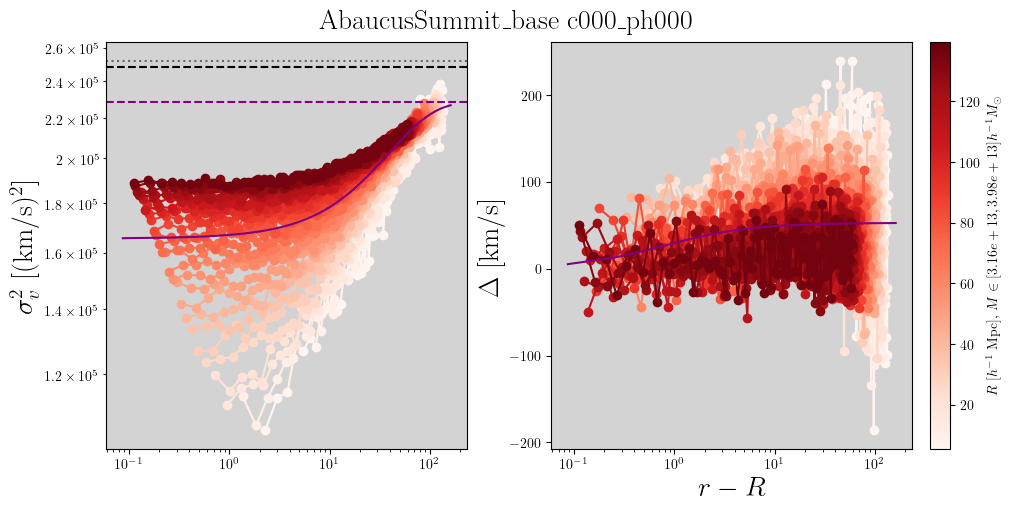

In [47]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


skip = 5


A_rho_R = np.full((len(r_p)//skip), np.nan)
A_rho_R_err = np.full(A_rho_R.shape, np.nan)


sig_rho_fix = sig_opts[-1]


fig, ax = plt.subplots(1, 2, figsize=(10, 5*1), layout='constrained', sharex=True)

fig.suptitle(rf"AbaucusSummit_base c000_ph000", fontsize=20)

for k in range(1):

    mean_vr_interp = mean_vr_r_interp

    Delta = ST_pars[:, :, 0] - mean_vr_interp(r) * r_l / r
    com_inputs = [(meas_sigv)**2, Delta]

    smask = np.isfinite((meas_sigv).flatten()) #& ((meas_sigv).flatten() > 0.1)
    dmask = np.isfinite(Delta.flatten()) #& (Delta.flatten() > -1000)

    # fit models to each input 

    popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], ((meas_sigv)).flatten()[smask], p0=[sigma, 0.3, 10], maxfev=5_000, absolute_sigma=False)
    popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

    sig_opts = popt_sig
    sig_errs = np.sqrt(np.diag(sig_cov))
    del_opts = popt_del 
    del_errs = np.sqrt(np.diag(del_cov))


    xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

    for j in range(0, len(r_p), skip):
        for i in range(2):

            y = com_inputs[i][j, :]
            
            if i == 0:
                mask = y > 0.1

                # if j == 0:
                #     popt, pcov = curve_fit(lambda x, A, s: sigma_mod(x, sig_opts[k, 0], A, s), x2[:, j], meas_sigv[k, j, :], p0=popt_sig[1:], maxfev=5_000, absolute_sigma=True)
                #     A_rho_R[k, j//skip], sig_rho_fix = popt
                #     A_rho_R_err[k, j//skip] = np.sqrt(pcov[0, 0])

                #     ax[i].plot(xs, sigma_mod(xs, sig_opts[k, 0], *popt )**2, c=cmaps[k][j], ls='--')

                # else:
                #     popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[k, 0], A, sig_rho_fix), x2[:, j], meas_sigv[k, j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)

                #     A_rho_R[k, j//skip] = popt
                #     A_rho_R_err[k, j//skip] = np.sqrt(pcov)

                #     ax[i].plot(xs, sigma_mod(xs, sig_opts[k, 0], popt, sig_rho_fix )**2, c=cmaps[k][j], ls='--')

            if i == 1:
                mask = y > -1000

            ax[i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[3][j])

            ax[i].set_facecolor('lightgray')
            
            ax[i].set_ylabel(names[i], fontsize=20)
            
            ax[i].set_xscale('log')
            
    norm = Normalize(vmin=min(r_p), vmax=max(r_p))
    sm = ScalarMappable(norm=norm, cmap=colormap_list[3])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax[-1])
    cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc], $M\in[{massbins[3, 0]:.2e}, {massbins[3, 1]:.2e}] h^{{-1}} M_\odot $", fontsize=10)

    ax[0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
    #ax[0].set_ylim((140_000, 300_000))
    ax[0].set_xscale('log')
    ax[0].axhline(2*(sigma)**2, c='k', ls='--')
    ax[0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
    ax[0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
    ax[0].set_yscale('log')

    #ax[0].set_xlabel(r'$r-R$', fontsize=20)
    ax[1].set_xlabel(r'$r-R$', fontsize=20)

    ax[1].plot(xs, delta_mod(xs, *popt_del), c='purple')
    print(popt_del)
    #ax[1].set_ylim((-500, 450))

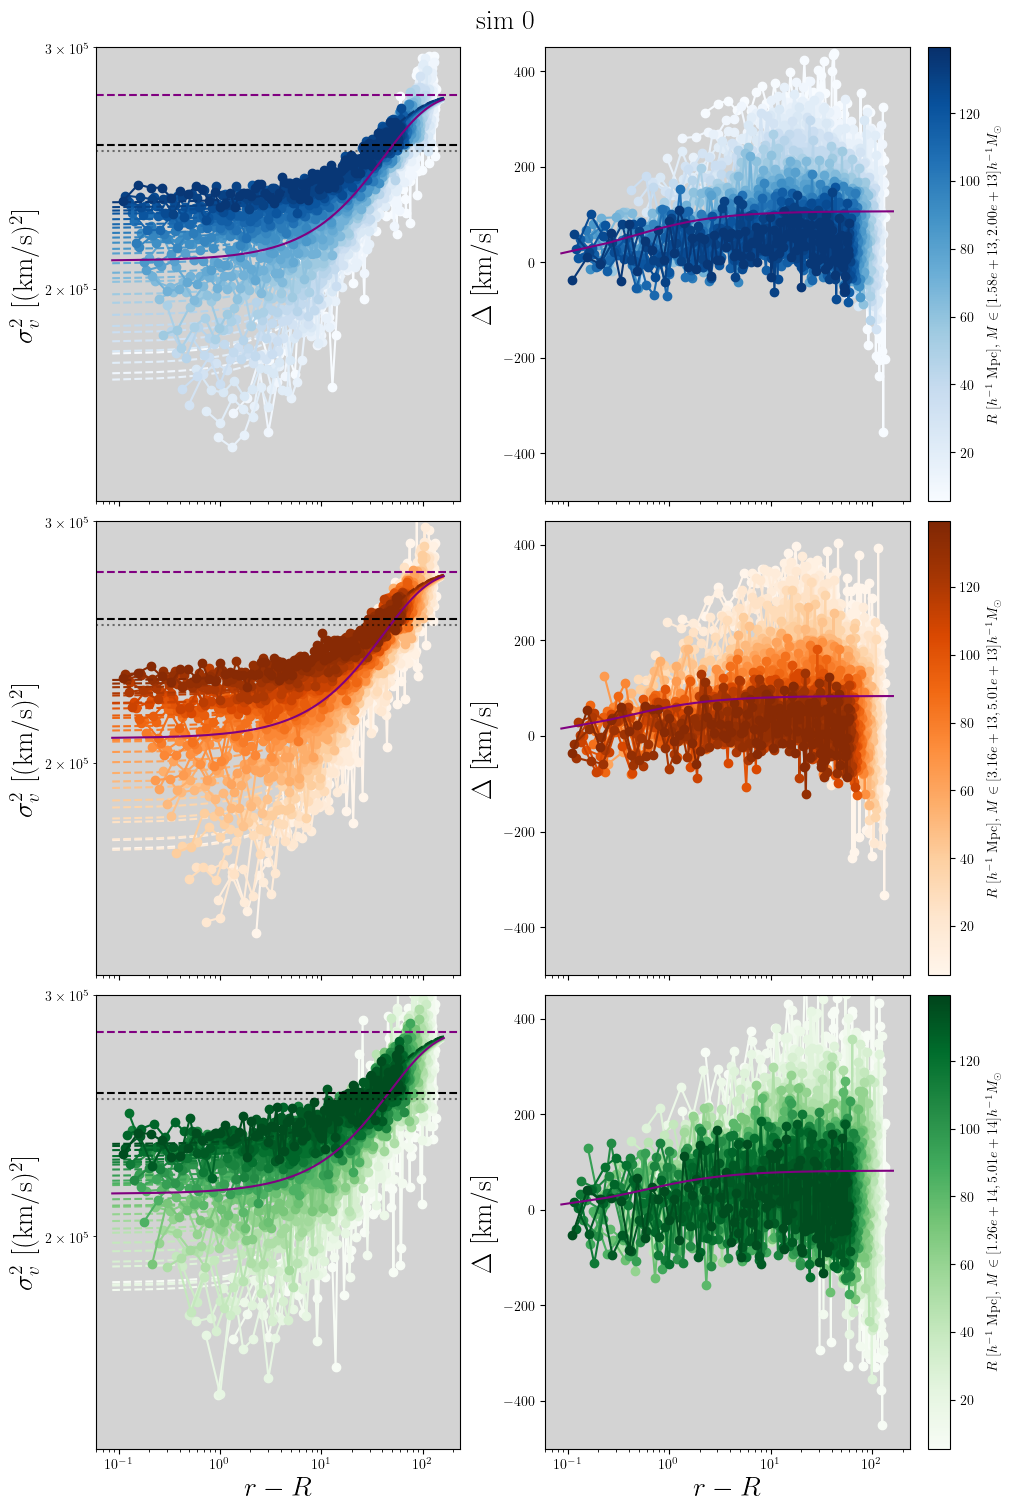

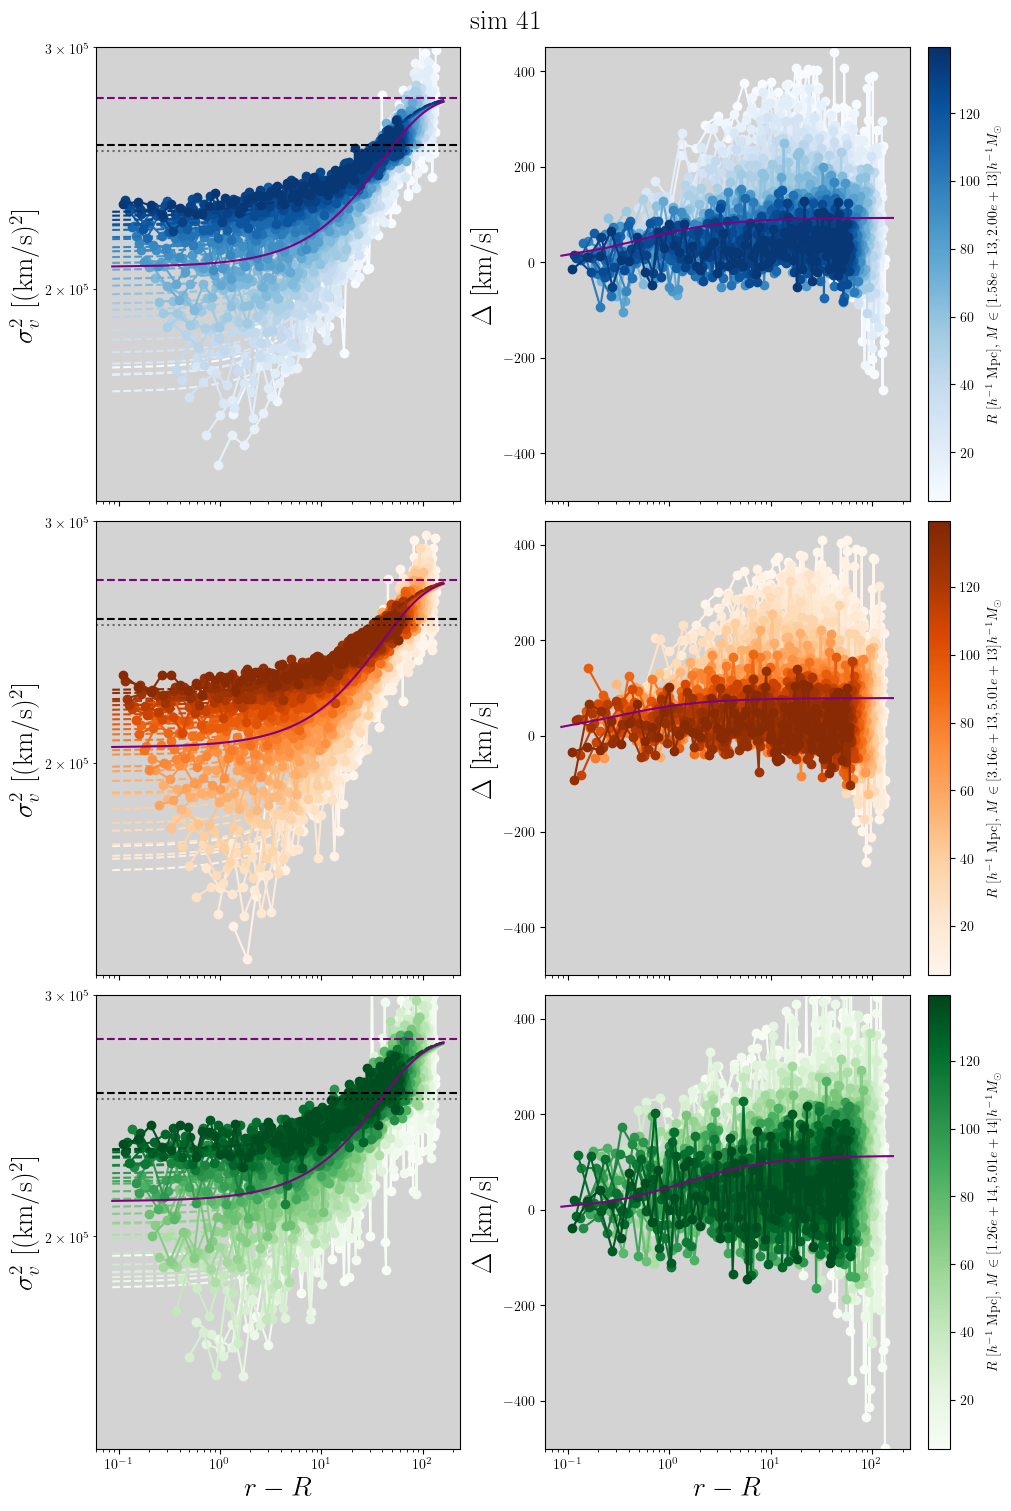

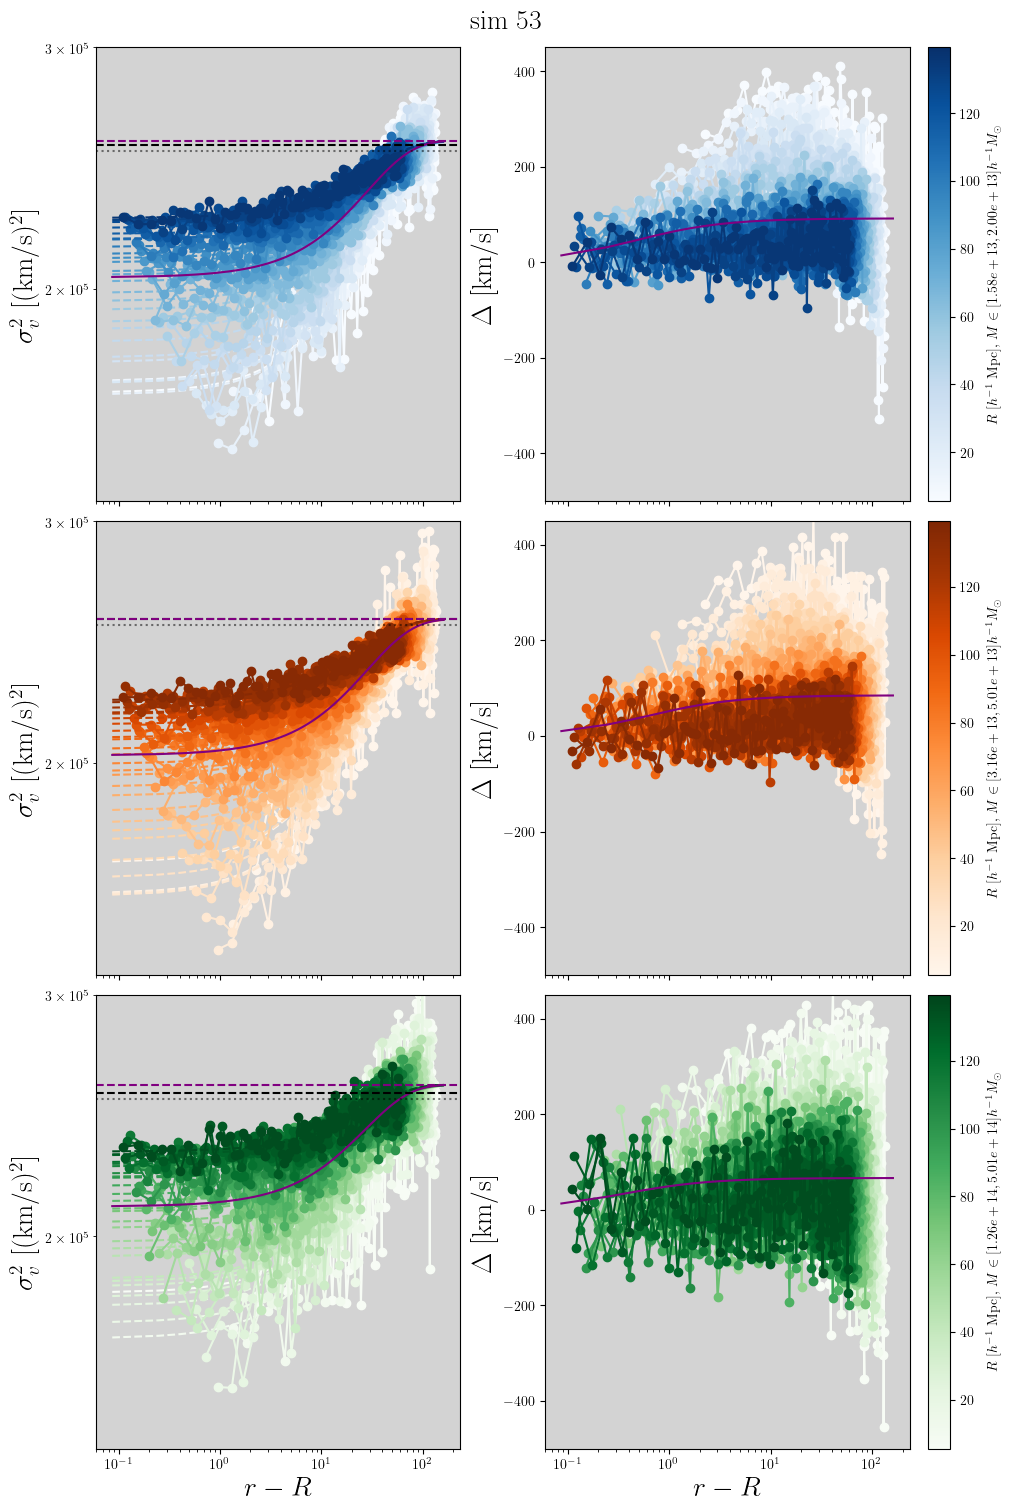

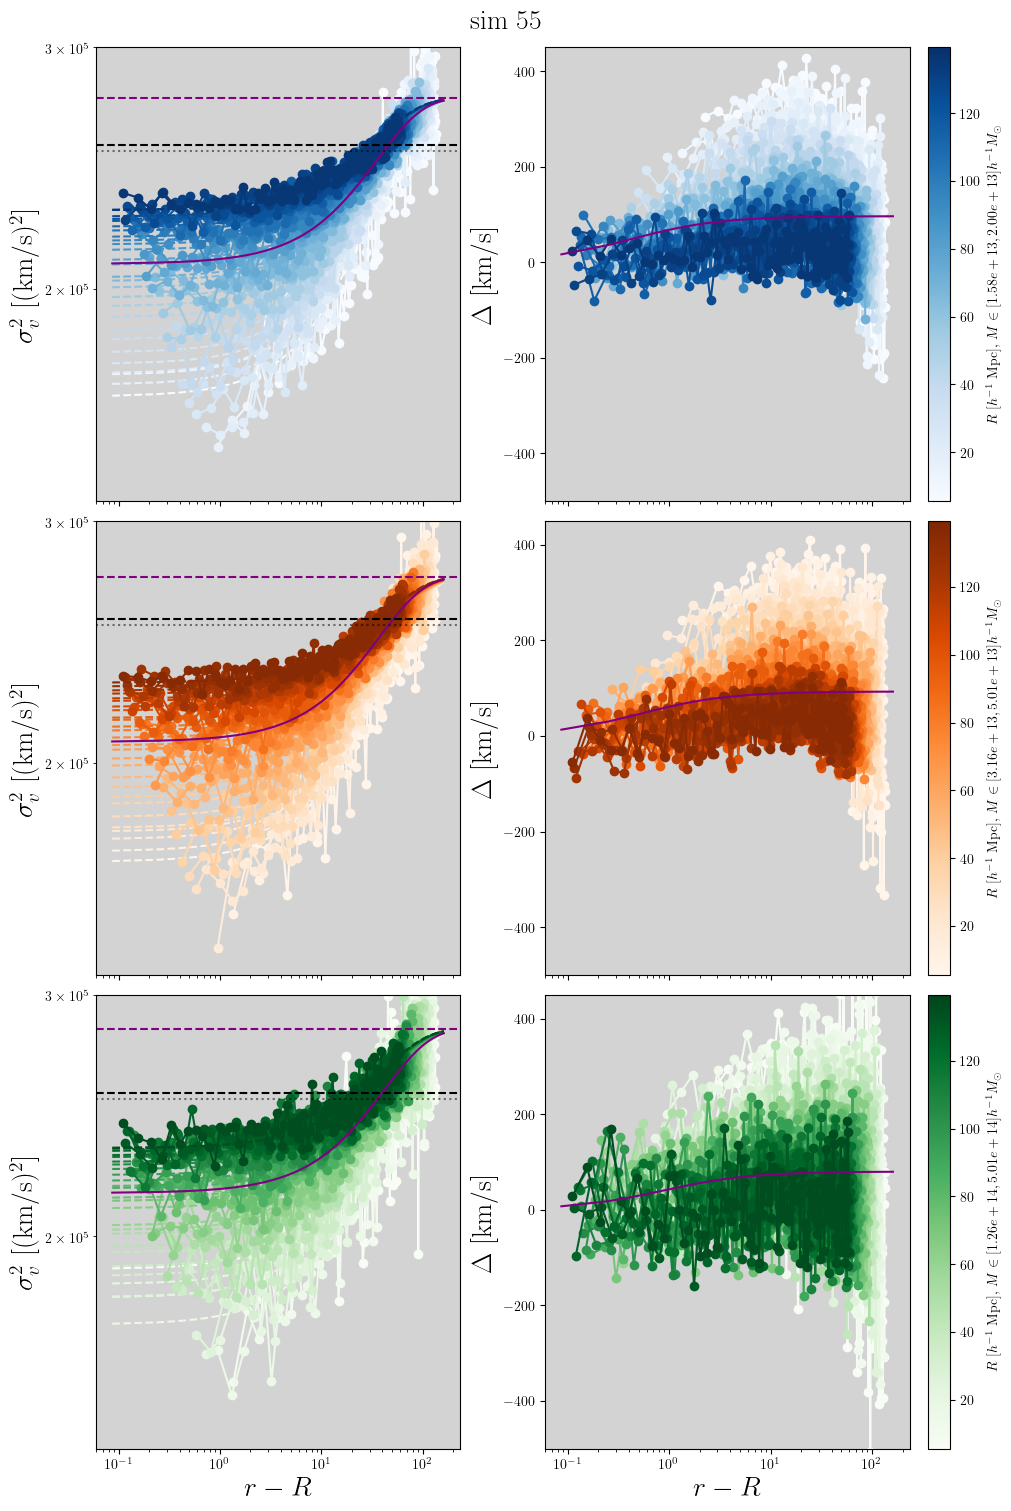

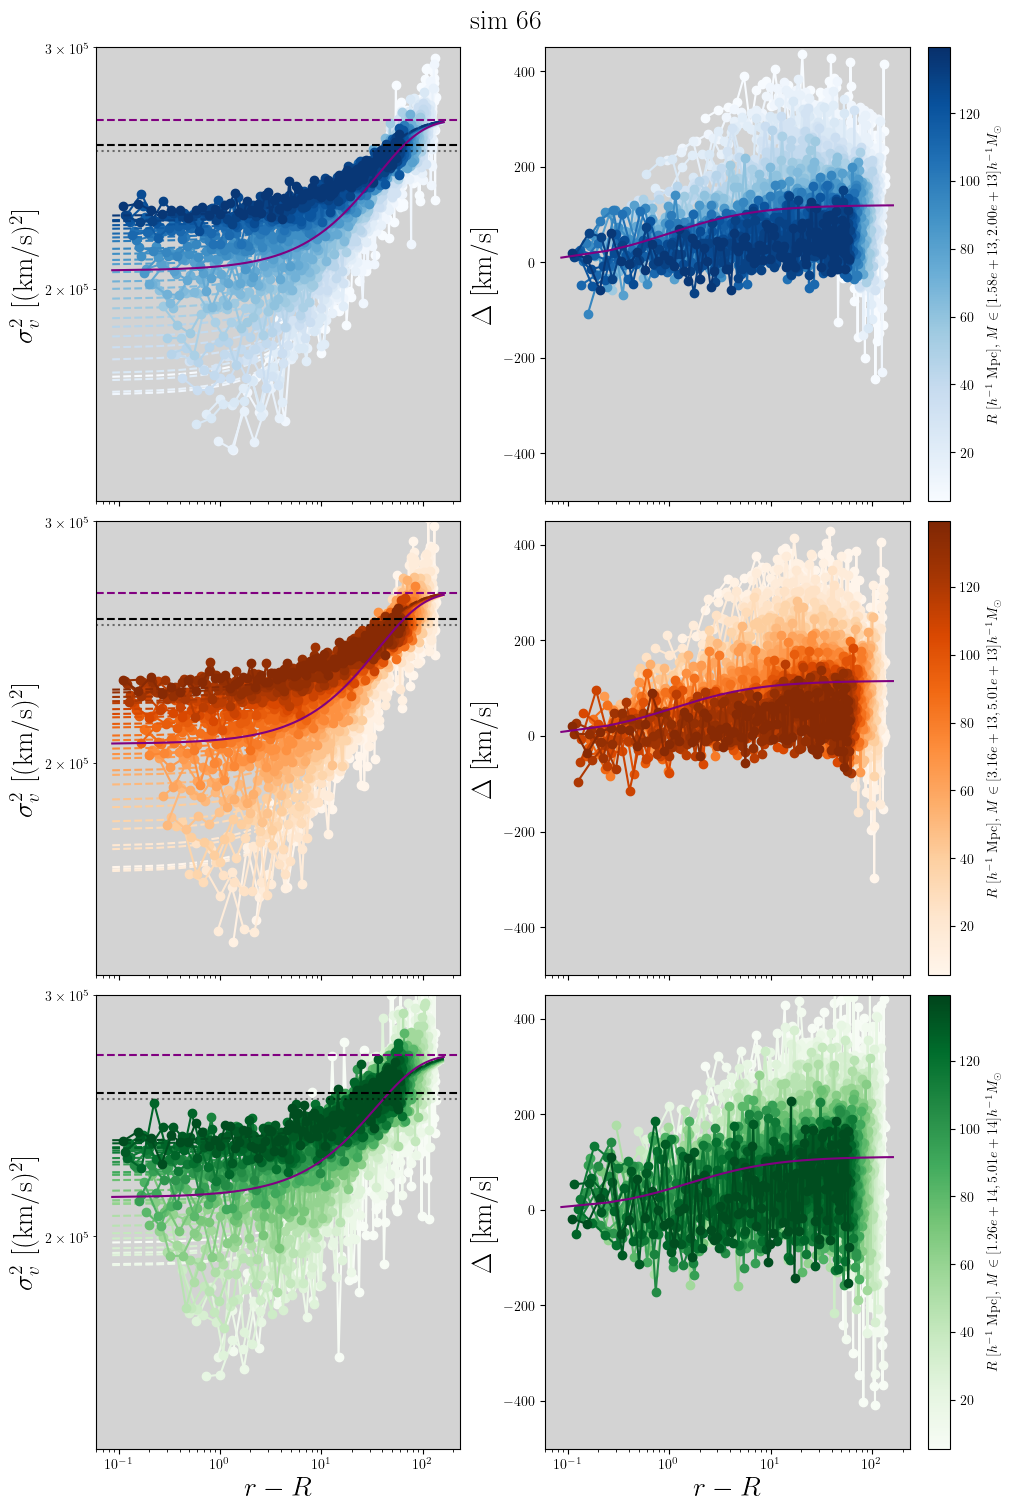

In [ ]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((len(cosmo_nums), len(M_cens), 3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((len(cosmo_nums), len(M_cens), 2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


skip = 5


A_rho_R = np.full((len(cosmo_nums), len(M_cens), len(r_p)//skip), np.nan)
A_rho_R_err = np.full(A_rho_R.shape, np.nan)


sig_rho_fix = sig_opts[:, :, -1]


for sim in range(len(cosmo_nums)):
    fig, ax = plt.subplots(len(M_cens), 2, figsize=(10, 5*len(M_cens)), layout='constrained', sharex=True)

    fig.suptitle(rf"sim {cosmo_nums[sim]}", fontsize=20)

    for k in range(len(M_cens)):

        mean_vr_interp = mean_vr_r_m_interps[sim][k]

        Delta = ST_pars[sim, k, :, :, 0] - mean_vr_interp(r) * r_l / r
        com_inputs = [meas_sigv[sim, k]**2, Delta]

        smask = np.isfinite(meas_sigv[sim, k].flatten()) & (meas_sigv[sim, k].flatten() > 0.1)
        dmask = np.isfinite(Delta.flatten()) & (Delta.flatten() > -1000)

        # fit models to each input 

        popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], (meas_sigv[sim, k]).flatten()[smask], p0=[sigma, 0.3, 10], maxfev=5_000, absolute_sigma=False)
        popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

        sig_opts[sim, k] = popt_sig
        sig_errs[sim, k] = np.sqrt(np.diag(sig_cov))
        del_opts[sim, k] = popt_del 
        del_errs[sim, k] = np.sqrt(np.diag(del_cov))


        xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

        for j in range(0, len(r_p), skip):
            for i in range(2):

                y = com_inputs[i][j, :]
                
                if i == 0:
                    mask = y > 0.1

                    if j == 0:
                        popt, pcov = curve_fit(lambda x, A, s: sigma_mod(x, sig_opts[sim, k, 0], A, s), x2[:, j], meas_sigv[sim, k, j, :], p0=popt_sig[1:], maxfev=5_000, absolute_sigma=True)
                        A_rho_R[sim, k, j//skip], sig_rho_fix = popt
                        A_rho_R_err[sim, k, j//skip] = np.sqrt(pcov[0, 0])

                        ax[k, i].plot(xs, sigma_mod(xs, sig_opts[sim, k, 0], *popt )**2, c=cmaps[k][j], ls='--')

                    else:
                        popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[sim, k, 0], A, sig_rho_fix), x2[:, j], meas_sigv[sim, k, j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)

                        A_rho_R[sim, k, j//skip] = popt
                        A_rho_R_err[sim, k, j//skip] = np.sqrt(pcov)

                        ax[k, i].plot(xs, sigma_mod(xs, sig_opts[sim, k, 0], popt, sig_rho_fix )**2, c=cmaps[k][j], ls='--')

                if i == 1:
                    mask = y > -1000

                ax[k, i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[k][j])

                ax[k, i].set_facecolor('lightgray')
                
                ax[k, i].set_ylabel(names[i], fontsize=20)
                
                ax[k, i].set_xscale('log')
                
        norm = Normalize(vmin=min(r_p), vmax=max(r_p))
        sm = ScalarMappable(norm=norm, cmap=colormap_list[k])
        sm.set_array([])  # dummy array
        cbar = fig.colorbar(sm, ax=ax[k, -1])
        cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc], $M\in[{massbins[k, 0]:.2e}, {massbins[k, 1]:.2e}] h^{{-1}} M_\odot $", fontsize=10)

        ax[k, 0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
        ax[k, 0].set_ylim((140_000, 300_000))
        ax[k, 0].set_xscale('log')
        ax[k, 0].axhline(2*(sigma)**2, c='k', ls='--')
        ax[k, 0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
        ax[k, 0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
        ax[k, 0].set_yscale('log')

        ax[-1, 0].set_xlabel(r'$r-R$', fontsize=20)
        ax[-1, 1].set_xlabel(r'$r-R$', fontsize=20)

        ax[k, 1].plot(xs, delta_mod(xs, *popt_del), c='purple')
        ax[k, 1].set_ylim((-500, 450))

In [4]:
# test pairwise velocity histograms "accumulator" method

"""Streaming histogram accumulator for P(v_los | M, R, rlos).

Replaces the raw pair catalogue: pairs are binned as they are produced and
then discarded.  Accumulators are additive, so each sub-box / simulation
worker builds its own and the results are summed.
"""


class PairHist:
    """4-D count histogram over (mass bin, R bin, rlos bin, v bin).

    Also tracks per-cell n, sum(v), sum(v^2) over *all* pairs landing in the
    (M, R, rlos) cell, including those outside the velocity grid.  So
    ``n - counts.sum(-1)`` is the number of pairs that fell off the v grid --
    a direct check that ``v_lo``/``v_hi`` are wide enough.
    """

    def __init__(self, n_M, R_edges, rlos_edges, v_lo, v_hi, n_v):
        self.n_M = int(n_M)
        self.R_edges = np.asarray(R_edges, dtype=np.float64)
        self.rlos_edges = np.asarray(rlos_edges, dtype=np.float64)
        self.v_lo = float(v_lo)
        self.v_hi = float(v_hi)
        self.n_v = int(n_v)

        self.n_R = len(self.R_edges) - 1
        self.n_l = len(self.rlos_edges) - 1
        self._inv_dv = self.n_v / (self.v_hi - self.v_lo)

        shape = (self.n_M, self.n_R, self.n_l)
        self.counts = np.zeros(shape + (self.n_v,), dtype=np.int64)
        self.n = np.zeros(shape, dtype=np.int64)
        self.sum_v = np.zeros(shape, dtype=np.float64)
        self.sum_v2 = np.zeros(shape, dtype=np.float64)

    @property
    def v_edges(self):
        return np.linspace(self.v_lo, self.v_hi, self.n_v + 1)

    @property
    def v_centers(self):
        e = self.v_edges
        return 0.5 * (e[1:] + e[:-1])

    def add(self, m_bin, R, rlos, v):
        """Bin a batch of pairs.  ``m_bin`` may be a scalar or a per-pair array."""
        R = np.asarray(R)
        rlos = np.asarray(rlos)
        v = np.asarray(v)

        iR = np.searchsorted(self.R_edges, R, side="right") - 1
        il = np.searchsorted(self.rlos_edges, rlos, side="right") - 1
        iv = np.floor((v - self.v_lo) * self._inv_dv).astype(np.int64)
        im = np.broadcast_to(np.asarray(m_bin, dtype=np.int64), R.shape)

        ok = ((iR >= 0) & (iR < self.n_R)
              & (il >= 0) & (il < self.n_l)
              & (im >= 0) & (im < self.n_M))

        cell = (im[ok] * self.n_R + iR[ok]) * self.n_l + il[ok]
        v_ok = v[ok]
        n_cell = self.n.size
        self.n += np.bincount(cell, minlength=n_cell).reshape(self.n.shape)
        self.sum_v += np.bincount(
            cell, weights=v_ok, minlength=n_cell).reshape(self.n.shape)
        self.sum_v2 += np.bincount(
            cell, weights=v_ok * v_ok, minlength=n_cell).reshape(self.n.shape)

        in_v = ok & (iv >= 0) & (iv < self.n_v)
        flat = ((im[in_v] * self.n_R + iR[in_v]) * self.n_l
                + il[in_v]) * self.n_v + iv[in_v]
        self.counts += np.bincount(
            flat, minlength=self.counts.size).reshape(self.counts.shape)

    def __iadd__(self, other):
        if (self.counts.shape != other.counts.shape
                or not np.array_equal(self.R_edges, other.R_edges)
                or not np.array_equal(self.rlos_edges, other.rlos_edges)
                or (self.v_lo, self.v_hi) != (other.v_lo, other.v_hi)):
            raise ValueError("accumulators were built on different grids")
        self.counts += other.counts
        self.n += other.n
        self.sum_v += other.sum_v
        self.sum_v2 += other.sum_v2
        return self

    def save(self, path):
        with h5.File(path, "w") as hdf:
            hdf.create_dataset("counts", data=self.counts, compression="gzip")
            hdf.create_dataset("n", data=self.n)
            hdf.create_dataset("sum_v", data=self.sum_v)
            hdf.create_dataset("sum_v2", data=self.sum_v2)
            hdf.create_dataset("R_edges", data=self.R_edges)
            hdf.create_dataset("rlos_edges", data=self.rlos_edges)
            hdf.attrs.update(n_M=self.n_M, v_lo=self.v_lo,
                             v_hi=self.v_hi, n_v=self.n_v)

    @classmethod
    def load(cls, path):
        with h5.File(path, "r") as hdf:
            obj = cls(hdf.attrs["n_M"], hdf["R_edges"][()],
                      hdf["rlos_edges"][()], hdf.attrs["v_lo"],
                      hdf.attrs["v_hi"], hdf.attrs["n_v"])
            obj.counts = hdf["counts"][()]
            obj.n = hdf["n"][()]
            obj.sum_v = hdf["sum_v"][()]
            obj.sum_v2 = hdf["sum_v2"][()]
        return obj


def reduce_hists(hists):
    """Sum a sequence of PairHist into the first one."""
    total = hists[0]
    for h in hists[1:]:
        total += h
    return total

In [5]:
"""Streaming histogram accumulator for P(v_los | M, R, rlos).

Replaces the raw pair catalogue: pairs are binned as they are produced and
then discarded.  Accumulators are additive, so each sub-box / simulation
worker builds its own and the results are summed.
"""

import numpy as np
import h5py as h5


class PairHist:
    """4-D count histogram over (mass bin, R bin, rlos bin, v_los bin).

    Also tracks per-cell n, sum(v), sum(v^2) -- and, when v_r is supplied,
    sum(v_r), sum(v_r^2) -- over *all* pairs landing in the (M, R, rlos) cell,
    including those outside the velocity grid.  So ``n - counts.sum(-1)`` is
    the number of pairs that fell off the v grid.
    """

    def __init__(self, n_M, R_edges, rlos_edges, v_lo, v_hi, n_v):
        self.n_M = int(n_M)
        self.R_edges = np.asarray(R_edges, dtype=np.float64)
        self.rlos_edges = np.asarray(rlos_edges, dtype=np.float64)
        self.v_lo = float(v_lo)
        self.v_hi = float(v_hi)
        self.n_v = int(n_v)

        self.n_R = len(self.R_edges) - 1
        self.n_l = len(self.rlos_edges) - 1
        self._inv_dv = self.n_v / (self.v_hi - self.v_lo)

        shape = (self.n_M, self.n_R, self.n_l)
        self.counts = np.zeros(shape + (self.n_v,), dtype=np.int64)
        self.n = np.zeros(shape, dtype=np.int64)
        self.sum_v = np.zeros(shape, dtype=np.float64)
        self.sum_v2 = np.zeros(shape, dtype=np.float64)
        self.sum_vr = np.zeros(shape, dtype=np.float64)
        self.sum_vr2 = np.zeros(shape, dtype=np.float64)

    @property
    def v_edges(self):
        return np.linspace(self.v_lo, self.v_hi, self.n_v + 1)

    @property
    def v_centers(self):
        e = self.v_edges
        return 0.5 * (e[1:] + e[:-1])

    def add(self, m_bin, R, rlos, v, vr=None):
        """Bin a batch of pairs.  ``m_bin`` may be a scalar or a per-pair array."""
        R = np.asarray(R)
        rlos = np.asarray(rlos)
        v = np.asarray(v)

        iR = np.searchsorted(self.R_edges, R, side="right") - 1
        il = np.searchsorted(self.rlos_edges, rlos, side="right") - 1
        iv = np.floor((v - self.v_lo) * self._inv_dv).astype(np.int64)
        im = np.broadcast_to(np.asarray(m_bin, dtype=np.int64), R.shape)

        ok = ((iR >= 0) & (iR < self.n_R)
              & (il >= 0) & (il < self.n_l)
              & (im >= 0) & (im < self.n_M))

        cell = (im[ok] * self.n_R + iR[ok]) * self.n_l + il[ok]
        v_ok = v[ok]
        n_cell = self.n.size
        shp = self.n.shape
        self.n += np.bincount(cell, minlength=n_cell).reshape(shp)
        self.sum_v += np.bincount(cell, weights=v_ok, minlength=n_cell).reshape(shp)
        self.sum_v2 += np.bincount(
            cell, weights=v_ok * v_ok, minlength=n_cell).reshape(shp)

        if vr is not None:
            vr_ok = np.asarray(vr)[ok]
            self.sum_vr += np.bincount(
                cell, weights=vr_ok, minlength=n_cell).reshape(shp)
            self.sum_vr2 += np.bincount(
                cell, weights=vr_ok * vr_ok, minlength=n_cell).reshape(shp)

        in_v = ok & (iv >= 0) & (iv < self.n_v)
        flat = ((im[in_v] * self.n_R + iR[in_v]) * self.n_l
                + il[in_v]) * self.n_v + iv[in_v]
        self.counts += np.bincount(
            flat, minlength=self.counts.size).reshape(self.counts.shape)

    def mean_std(self, k, radial=False):
        """Per-cell (mean, std) of v_los, or of v_r when radial=True."""
        n = np.where(self.n[k] > 0, self.n[k], np.nan)
        s1 = (self.sum_vr if radial else self.sum_v)[k]
        s2 = (self.sum_vr2 if radial else self.sum_v2)[k]
        mu = s1 / n
        return mu, np.sqrt(np.maximum(s2 / n - mu ** 2, 0.0))

    def __iadd__(self, other):
        if (self.counts.shape != other.counts.shape
                or not np.array_equal(self.R_edges, other.R_edges)
                or not np.array_equal(self.rlos_edges, other.rlos_edges)
                or (self.v_lo, self.v_hi) != (other.v_lo, other.v_hi)):
            raise ValueError("accumulators were built on different grids")
        self.counts += other.counts
        self.n += other.n
        self.sum_v += other.sum_v
        self.sum_v2 += other.sum_v2
        self.sum_vr += other.sum_vr
        self.sum_vr2 += other.sum_vr2
        return self

    def save(self, path):
        with h5.File(path, "w") as hdf:
            hdf.create_dataset("counts", data=self.counts, compression="gzip")
            for name in ("n", "sum_v", "sum_v2", "sum_vr", "sum_vr2"):
                hdf.create_dataset(name, data=getattr(self, name))
            hdf.create_dataset("R_edges", data=self.R_edges)
            hdf.create_dataset("rlos_edges", data=self.rlos_edges)
            hdf.attrs.update(n_M=self.n_M, v_lo=self.v_lo,
                             v_hi=self.v_hi, n_v=self.n_v)

    @classmethod
    def load(cls, path):
        with h5.File(path, "r") as hdf:
            obj = cls(hdf.attrs["n_M"], hdf["R_edges"][()],
                      hdf["rlos_edges"][()], hdf.attrs["v_lo"],
                      hdf.attrs["v_hi"], hdf.attrs["n_v"])
            obj.counts = hdf["counts"][()]
            for name in ("n", "sum_v", "sum_v2", "sum_vr", "sum_vr2"):
                if name in hdf:            # files written before v_r was added
                    setattr(obj, name, hdf[name][()])
        return obj


def reduce_hists(hists):
    """Sum a sequence of PairHist into the first one."""
    total = hists[0]
    for h in hists[1:]:
        total += h
    return total

In [22]:
"""Stream the k=3 pairwise catalogue into a PairHist, in km/s.

Run in order:
    1. size_grid(mean_vr_r_interp, r_p, r_l)  -> tells you what V_LO / V_HI
                                                 must be; set them below
    2. validate()                             -> checks agreement with the
                                                 pd.cut / np.histogram path
    3. accumulate()                           -> writes the accumulator the
                                                 fit loop reads

Velocities are multiplied by CONV at accumulation time, so everything in the
saved file -- v grid, sum_v, sum_v2 -- is already in km/s and the fit loop
needs no conversion.
"""

# ---------------------------------------------------------------- config ----
pair_path = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
             'AbacusSummit_base_c000_ph000/halos/z0.200/data/'
             'pairwise_velocity_selections/'
             'halo_halo_pairs_no_vlos_cut_massbin_test_SB500.hdf5')

out_path = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
             'AbacusSummit_base_c000_ph000/halos/z0.200/data/'
            'pairhist_abacus_k3.h5')

CONV = conv                 # noqa: F821  <- your raw -> km/s factor

# Same edge arrays you pass to bin_pairwise_cat as R_bins / rlos_bins.
R_edges = r_perp            # noqa: F821
rlos_edges = r_los          # noqa: F821

# Velocity grid, in km/s.  Set these from what size_grid() prints.
V_LO, V_HI = -4000.0, 4000.0
DV = 20.0                   # fine bin width; rebinned by 5 -> 100 km/s in the fit

CHUNK = 20_000_000          # rows per read; ~480 MB for 3 float64 columns


def _n_v():
    n = int(round((V_HI - V_LO) / DV))
    assert n % 5 == 0, 'grid span must be a multiple of 5*DV for REBIN=5'
    return n


def _new_hist():
    h = PairHist(6, R_edges, rlos_edges, V_LO, V_HI, _n_v())
    print('grid: %d v bins of %.1f km/s over [%.0f, %.0f]; %.0f MB'
          % (h.n_v, DV, V_LO, V_HI, h.counts.nbytes / 1e6))
    return h


# ------------------------------------------------------------- step 1 ------
def size_grid(mean_vr_interp, r_p, r_l, n_sub=20_000_000):
    """Print the velocity range the grid has to cover, in km/s."""
    with h5.File(pair_path, 'r') as hdf:
        v = CONV * hdf[f'vpeclos'][:n_sub]
    print(f'data  (n={n_sub:,}): mean {v.mean():.1f}  std {v.std():.1f}  '
          f'min {v.min():.1f}  max {v.max():.1f}  km/s')

    peaks = np.array([mean_vr_interp(np.hypot(rp, rl))
                      * np.sin(np.arctan2(rl, rp))
                      for rp in r_p for rl in r_l])
    print(f'fit windows (peak +/- 2500): [{peaks.min() - 2500:.0f}, '
          f'{peaks.max() + 2500:.0f}] km/s')
    print('set V_LO / V_HI to cover BOTH lines above (round outwards).')


# ------------------------------------------------------------- step 2 ------
def validate(n_sub=20_000_000):
    """Compare against the current pd.cut / np.histogram path."""
    with h5.File(pair_path, 'r') as hdf:
        R = hdf[f'R'][:n_sub]
        rlos = hdf[f'rlos'][:n_sub]
        v = CONV * hdf[f'vpeclos'][:n_sub]

    h = _new_hist()
    h.add(k, R, rlos, v)

    df = pd.DataFrame({'R': R, 'rlos': rlos, 'vpeclos': v})
    df['R_bin'] = pd.cut(df['R'], bins=R_edges, labels=False, include_lowest=True)
    df['rlos_bin'] = pd.cut(df['rlos'], bins=rlos_edges, labels=False,
                            include_lowest=True)
    df = df.dropna(subset=['R_bin', 'rlos_bin'])
    df['R_bin'] = df['R_bin'].astype(int)
    df['rlos_bin'] = df['rlos_bin'].astype(int)

    ref = df.groupby(['R_bin', 'rlos_bin']).size()
    mine = pd.Series(h.n[k].ravel(),
                     index=pd.MultiIndex.from_product(
                         [range(h.n_R), range(h.n_l)]))
    mine = mine[mine > 0]
    diff = mine.subtract(ref, fill_value=0)
    print('rows  pd.cut / PairHist :', len(df), h.n.sum())
    print('cells differing         :', (diff != 0).sum(),
          ' max |diff|:', diff.abs().max())

    # the check that would have caught the units bug: is the velocity axis
    # actually resolved, or is everything piled into one bin?
    j, i = np.unravel_index(np.argmax(h.n[k]), h.n[k].shape)
    occ = (h.counts[k, j, i] > 0).sum()
    print(f'cell ({j},{i}) n={h.n[k, j, i]}: {occ} of {h.n_v} v bins occupied')
    assert occ > 20, 'velocity grid is far too wide -- check CONV / V_LO / V_HI'

    cell = df[(df.R_bin == j) & (df.rlos_bin == i)]['vpeclos'].values
    edges = np.arange(V_LO, V_HI + 1, DV * 5)
    ref_hist, _ = np.histogram(cell, bins=edges)
    mine_hist = h.counts[k, j, i].reshape(-1, 5).sum(axis=1)
    print('max |hist diff| at 100 km/s:', np.abs(mine_hist - ref_hist).max())

    mu = h.sum_v[k, j, i] / h.n[k, j, i]
    print('mean  pd.cut / PairHist :', cell.mean(), mu)
    print('std   pd.cut / PairHist :', cell.std(),
          np.sqrt(h.sum_v2[k, j, i] / h.n[k, j, i] - mu ** 2))


# ------------------------------------------------------------- step 3 ------
def accumulate():
    h = _new_hist()
    with h5.File(pair_path, 'r') as hdf:
        N = hdf[f'R'].shape[0]
        print(f'{N:,} pairs in {int(np.ceil(N / CHUNK))} chunks')
        for lo in range(0, N, CHUNK):
            hi = min(lo + CHUNK, N)
            h.add(k,
                  hdf[f'R'][lo:hi],
                  hdf[f'rlos'][lo:hi],
                  CONV * hdf[f'vpeclos'][lo:hi])
            print(f'  {hi:,} / {N:,}', end='\r', flush=True)

    print()
    print('rows in range     :', h.n.sum(), 'of', N)
    print('off the v grid    :', (h.n - h.counts.sum(-1)).sum(), '(want 0)')
    print('occupied cells    :', (h.n[k] > 0).sum(), 'of', h.n[k].size)
    print('median cell count :', np.median(h.n[k][h.n[k] > 0]))
    v_occ = (h.counts[k] > 0).sum(axis=-1)
    print('v bins occupied   : median %.0f, max %d of %d'
          % (np.median(v_occ[h.n[k] > 0]), v_occ.max(), h.n_v))
    h.save(out_path)
    print('saved', out_path)
    return h

In [23]:
size_grid(mean_vr_r_interp, r_p, r_l)   # prints the range; set V_LO/V_HI, re-import
validate()                              # want: cells differing ~2365, |diff| <= 2
accumulate()                            # ~10 min

data  (n=20,000,000): mean -9.3  std 436.2  min -3118.8  max 3425.5  km/s
fit windows (peak +/- 2500): [-2500, 2500] km/s
set V_LO / V_HI to cover BOTH lines above (round outwards).
grid: 400 v bins of 20.0 km/s over [-4000, 4000]; 350 MB
rows  pd.cut / PairHist : 9676072 9676067
cells differing         : 2365  max |diff|: 2
cell (134,37) n=1108: 120 of 400 v bins occupied
max |hist diff| at 100 km/s: 0
mean  pd.cut / PairHist : -25.69994549135423 -25.699945491354256
std   pd.cut / PairHist : 433.3478259046749 433.34782590467483
grid: 400 v bins of 20.0 km/s over [-4000, 4000]; 350 MB
1,281,090,491 pairs in 65 chunks
  1,281,090,491 / 1,281,090,491
rows in range     : 616232534 of 1281090491
off the v grid    : 0 (want 0)
occupied cells    : 18225 of 18225
median cell count : 33810.0
v bins occupied   : median 186, max 215 of 400
saved /spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/pairhist_abacus_k3.h5


In [32]:


k     = 3
nus   = 6
REBIN = 5        # 20 km/s fine bins -> 100 km/s, matching your linspace(...,51)
N_MIN = 500      # replaces the isnan(hist) guard

h = PairHist.load(out_path)
assert len(r_p) == h.n_R and len(r_l) == h.n_l

k = int(np.argmax(h.n.sum(axis=(1, 2))))
print('using mass slot', k, 'with', h.n[k].sum(), 'rows')

cent_fine = h.v_centers                          # km/s, conv applied at accumulation
dv        = (cent_fine[1] - cent_fine[0]) * REBIN
cent      = cent_fine.reshape(-1, REBIN).mean(axis=1)

ST_pars_check = np.full((len(r_p), len(r_l), 3), np.nan)
ST_errs_check = np.full(ST_pars_check.shape, np.nan)

mean_vr_interp = mean_vr_r_interp

for j in range(len(r_p)):
    for i in range(len(r_l)):
        n = h.n[k, j, i]
        if n < N_MIN:
            continue

        r_3d  = np.sqrt(r_p[j]**2 + r_l[i]**2)
        theta = np.arctan2(r_l[i], r_p[j])
        sin   = np.sin(theta)

        peak = conv*mean_vr_interp(r_3d) * sin

        mu    = h.sum_v[k, j, i] / n
        width = np.sqrt(max(h.sum_v2[k, j, i] / n - mu**2, 0.0))

        counts   = h.counts[k, j, i].reshape(-1, REBIN).sum(axis=1)
        sel      = np.abs(cent - peak) <= 2500
        c_w, x_w = counts[sel], cent[sel]
        if c_w.sum() == 0:
            continue

        hist = c_w / (c_w.sum() * dv)            # matches density=True over the window

        try:
            p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                             x_w, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
        except RuntimeError:
            continue
        ST_pars_check[j, i] = p
        ST_errs_check[j, i] = np.sqrt(np.diag(c))

using mass slot 0 with 616232534 rows


In [33]:
np.isnan(ST_pars_check).sum()/len(ST_pars_check.flatten())

np.float64(0.0)

In [13]:
n = h.n[k].astype(float)
n[n < N_MIN] = np.nan
mu = h.sum_v[k] / n
meas_sigv_check = np.sqrt(h.sum_v2[k] / n - mu**2)

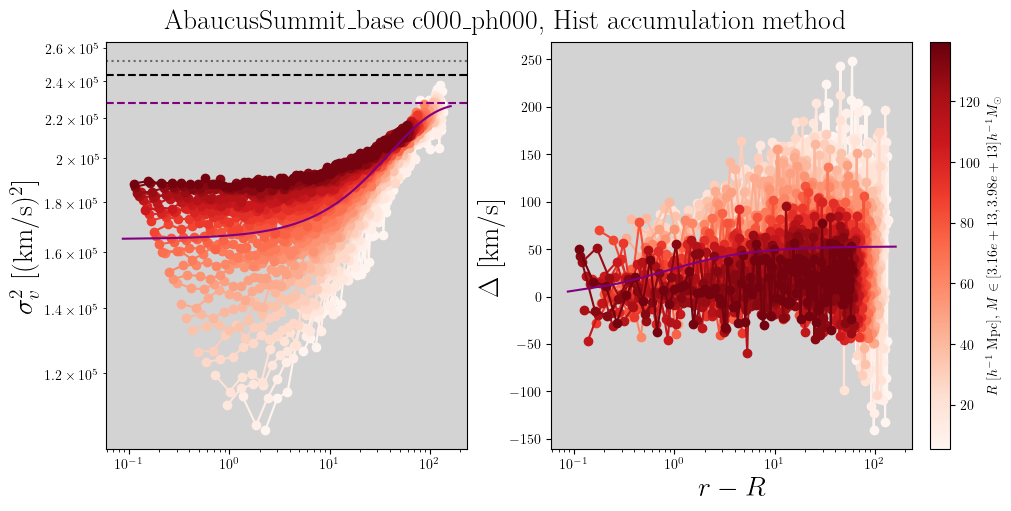

In [35]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


skip = 5


A_rho_R = np.full((len(r_p)//skip), np.nan)
A_rho_R_err = np.full(A_rho_R.shape, np.nan)


sig_rho_fix = sig_opts[-1]


fig, ax = plt.subplots(1, 2, figsize=(10, 5*1), layout='constrained', sharex=True)

fig.suptitle(rf"AbaucusSummit_base c000_ph000, Hist accumulation method", fontsize=20)

for k in range(1):

    mean_vr_interp = mean_vr_r_interp

    Delta = ST_pars_check[:, :, 0] - mean_vr_interp(r) * r_l / r
    com_inputs = [(meas_sigv_check)**2, Delta]

    smask = np.isfinite((meas_sigv_check).flatten()) #& ((meas_sigv_check).flatten() > 0.1)
    dmask = np.isfinite(Delta.flatten()) #& (Delta.flatten() > -1000)

    # fit models to each input 

    popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], ((meas_sigv_check)).flatten()[smask], p0=[sigma, 0.3, 10], maxfev=5_000, absolute_sigma=False)
    popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

    sig_opts = popt_sig
    sig_errs = np.sqrt(np.diag(sig_cov))
    del_opts = popt_del 
    del_errs = np.sqrt(np.diag(del_cov))


    xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

    for j in range(0, len(r_p), skip):
        for i in range(2):

            y = com_inputs[i][j, :]
            
            if i == 0:
                mask = y > 0.1

                # if j == 0:
                #     popt, pcov = curve_fit(lambda x, A, s: sigma_mod(x, sig_opts[k, 0], A, s), x2[:, j], meas_sigv_check[k, j, :], p0=popt_sig[1:], maxfev=5_000, absolute_sigma=True)
                #     A_rho_R[k, j//skip], sig_rho_fix = popt
                #     A_rho_R_err[k, j//skip] = np.sqrt(pcov[0, 0])

                #     ax[i].plot(xs, sigma_mod(xs, sig_opts[k, 0], *popt )**2, c=cmaps[k][j], ls='--')

                # else:
                #     popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[k, 0], A, sig_rho_fix), x2[:, j], meas_sigv_check[k, j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)

                #     A_rho_R[k, j//skip] = popt
                #     A_rho_R_err[k, j//skip] = np.sqrt(pcov)

                #     ax[i].plot(xs, sigma_mod(xs, sig_opts[k, 0], popt, sig_rho_fix )**2, c=cmaps[k][j], ls='--')

            if i == 1:
                mask = y > -1000

            ax[i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[3][j])

            ax[i].set_facecolor('lightgray')
            
            ax[i].set_ylabel(names[i], fontsize=20)
            
            ax[i].set_xscale('log')
            
    norm = Normalize(vmin=min(r_p), vmax=max(r_p))
    sm = ScalarMappable(norm=norm, cmap=colormap_list[3])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax[-1])
    cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc], $M\in[{massbins[3, 0]:.2e}, {massbins[3, 1]:.2e}] h^{{-1}} M_\odot $", fontsize=10)

    ax[0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
    #ax[0].set_ylim((140_000, 300_000))
    ax[0].set_xscale('log')
    ax[0].axhline(2*(sigma)**2, c='k', ls='--')
    ax[0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
    ax[0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
    ax[0].set_yscale('log')

    #ax[0].set_xlabel(r'$r-R$', fontsize=20)
    ax[1].set_xlabel(r'$r-R$', fontsize=20)

    ax[1].plot(xs, delta_mod(xs, *popt_del), c='purple')
    #ax[1].set_ylim((-500, 450))

In [6]:
# compile histograms for all masses with PairHist method

"""Pair search that accumulates into a PairHist instead of returning pairs.

Drop-in replacement for get_pairwise_halo_pw_quants.  Differences:

  * takes seed arrays, not a file path -- the caller reads the catalogue once
    instead of once per mass bin
  * takes a per-seed mass-bin index, so ALL mass bins are done in ONE pair
    search rather than one search per bin
  * workers write their accumulator to a temp file and return the path, so the
    parent never holds 64 accumulators at once
  * v_r is computed and accumulated as per-cell moments (sum_vr, sum_vr2);
    v_t is not -- say so if step 5 needs it

Fill in the two imports below from your own module.
"""

import os
import tempfile

import numpy as np
from joblib import Parallel, delayed

# from accumulate import (load_halos, relative_coordinates, get_sub_box_id,  # noqa
#                         get_zw13_vr_vt)

FLUSH = 5_000_000        # pairs buffered per worker before a bincount sweep


class _Buffer:
    """Batches pairs so bincount is called once per FLUSH, not once per seed."""

    def __init__(self, hist, conv):
        self.h = hist
        self.conv = conv
        self.m, self.R, self.l, self.v, self.vr = [], [], [], [], []
        self.n = 0

    def add(self, m_bin, R, rlos, v, vr):
        self.m.append(np.full(R.size, m_bin, dtype=np.int32))
        self.R.append(R.astype(np.float32))
        self.l.append(rlos.astype(np.float32))
        self.v.append(v.astype(np.float32))
        self.vr.append(vr.astype(np.float32))
        self.n += R.size
        if self.n >= FLUSH:
            self.flush()

    def flush(self):
        if self.n == 0:
            return
        self.h.add(np.concatenate(self.m), np.concatenate(self.R),
                   np.concatenate(self.l), self.conv * np.concatenate(self.v),
                   self.conv * np.concatenate(self.vr))
        self.m, self.R, self.l, self.v, self.vr = [], [], [], [], []
        self.n = 0


def get_pairwise_hist(
    seed_pos, seed_vel, seed_mbin,
    r_max, boxsize, subsize, path,
    n_M, R_edges, rlos_edges, v_lo, v_hi, n_v,
    conv=1.0, n_jobs=-1, tmpdir=None,
):
    """seed_mbin : int array, mass-bin index per seed (use -1 to skip a seed)."""
    keep = seed_mbin >= 0
    seed_pos = seed_pos[keep] % boxsize
    seed_vel = seed_vel[keep]
    seed_mbin = seed_mbin[keep].astype(np.int32)

    sb_id = get_sub_box_id(seed_pos.copy(), boxsize, subsize)
    order = np.argsort(sb_id)
    sb_id, seed_pos, seed_vel, seed_mbin = (
        sb_id[order], seed_pos[order], seed_vel[order], seed_mbin[order])

    # slice boundaries so each worker gets only its own seeds
    uniq, starts = np.unique(sb_id, return_index=True)
    ends = np.append(starts[1:], len(sb_id))

    tmpdir = tmpdir or tempfile.mkdtemp(prefix='pairhist_')

    def _process_sub_box(sub_box_id, lo, hi):
        pos, vel, _, _, _ = load_halos(sub_box_id, boxsize, subsize, path)
        h = PairHist(n_M, R_edges, rlos_edges, v_lo, v_hi, n_v)
        buf = _Buffer(h, conv)

        sp, sv, sm = seed_pos[lo:hi], seed_vel[lo:hi], seed_mbin[lo:hi]
        for i in range(hi - lo):
            rel_pos = relative_coordinates(sp[i], pos, boxsize)

            close = ((np.abs(rel_pos[:, 0]) <= r_max)
                     & (np.abs(rel_pos[:, 1]) <= r_max)
                     & (np.abs(rel_pos[:, 2]) <= r_max))
            rel_pos = rel_pos[close]

            R = np.sqrt(rel_pos[:, 0]**2 + rel_pos[:, 1]**2)
            keep = (R <= r_max) & (R > 0)        # drops the self-pair
            if not keep.any():
                continue

            rel_pos = rel_pos[keep]
            rel_vel = vel[close][keep] - sv[i]
            vr, _ = get_zw13_vr_vt(rel_pos, rel_vel)

            buf.add(sm[i], R[keep], rel_pos[:, 2], rel_vel[:, 2], vr)

        buf.flush()
        out = os.path.join(tmpdir, f'sb_{sub_box_id}.h5')
        h.save(out)
        return out

    paths = Parallel(n_jobs=n_jobs)(
        delayed(_process_sub_box)(sb, lo, hi)
        for sb, lo, hi in zip(uniq, starts, ends))

    total = PairHist(n_M, R_edges, rlos_edges, v_lo, v_hi, n_v)
    for p in paths:
        total += PairHist.load(p)
        os.remove(p)
    os.rmdir(tmpdir)
    return total

In [10]:
"""End-to-end: raw AbacusSummit_base catalogue -> one PairHist file.

Produces exactly two things on disk:
  * the sub-box files under hsb_path (~200 MB, a spatially sorted copy of the
    M > 1e13 halos -- reusable across runs)
  * pairhist_abacus_allbins.h5 (~350 MB, all six mass bins)

No pair catalogue is ever written.

PREREQUISITES in split_simulation_into_sub_boxes:
  * the inner h5.File(...) open must be mode 'a', not 'w'
  * the chunk bound must be `if chunk < n_iter - 1`, not `n_iter - 2`
"""

import os
import shutil

# import numpy as np
# import h5py as h5

# from pairhist import PairHist
# from pairhist_direct import get_pairwise_hist
# from accumulate import generate_sub_box_ids, split_simulation_into_sub_boxes

# ---------------------------------------------------------------- config ----
box_length = 2000.0
subsize = box_length / 4          # 500 > r_max, as required
r_max = 140.0
M_NEIGHBOUR = 1e12                # tracer sample the seeds are paired against

log_edges = np.array([[12, 12.01], [12.5, 12.6], [13, 13.1],
                      [13.5, 13.6], [14.0, 14.2], [14.4, 14.7]])
massbins = 10**log_edges

halo_path = ('/spiff/hengweichang/AbacusSummit_base/snapshots/'
             'AbacusSummit_base_c000_ph000/halos/z0.200/halo_combined.h5')
hsb_path = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
            'AbacusSummit_base_c000_ph000/halos/z0.200/SBp/')
out_path = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
            'AbacusSummit_base_c000_ph000/halos/z0.200/data/'
            'pairhist_abacus_allbins.h5')

R_edges = r_perp                  # noqa: F821  your grids, edges not centres
rlos_edges = r_los                # noqa: F821
V_LO, V_HI, N_V = -4000.0, 4000.0, 400
CONV = conv                       # noqa: F821  raw -> km/s

REBUILD_SUBBOXES = True           # False to reuse an existing hsb_path
N_JOBS = 84

# ------------------------------------------------------- 1. read once ------
print('reading catalogue...')
with h5.File(halo_path, 'r') as hdf:
    hcat = hdf['halos'][:]

Mvir = m_p * hcat['N_total']      # noqa: F821
pos = np.array([hcat['x'], hcat['y'], hcat['z']]).T % box_length
vel = np.array([hcat['vx'], hcat['vy'], hcat['vz']]).T
hid = hcat['hid_cleaned']
del hcat

# ------------------------------------------- 2. neighbour (tracer) sample --
nb = Mvir >= M_NEIGHBOUR
print(f'neighbour sample: {nb.sum():,} halos, '
      f'n_bar = {nb.sum() / box_length**3:.3e} (h/Mpc)^3')
print(f'expected pairs/seed = {nb.sum() / box_length**3 * np.pi * r_max**2 * 2 * r_max:,.0f}')

reading catalogue...
neighbour sample: 31,212,324 halos, n_bar = 3.902e-03 (h/Mpc)^3
expected pairs/seed = 67,267


In [7]:
"""Streaming histogram accumulator for P(v_los | M, R, rlos).

Replaces the raw pair catalogue: pairs are binned as they are produced and
then discarded.  Accumulators are additive, so each sub-box / simulation
worker builds its own and the results are summed.
"""


class PairHist:
    """4-D count histogram over (mass bin, R bin, rlos bin, v_los bin).

    Also tracks per-cell n, sum(v), sum(v^2) -- and, when v_r is supplied,
    sum(v_r), sum(v_r^2) -- over *all* pairs landing in the (M, R, rlos) cell,
    including those outside the velocity grid.  So ``n - counts.sum(-1)`` is
    the number of pairs that fell off the v grid.
    """

    def __init__(self, n_M, R_edges, rlos_edges, v_lo, v_hi, n_v):
        self.n_M = int(n_M)
        self.R_edges = np.asarray(R_edges, dtype=np.float64)
        self.rlos_edges = np.asarray(rlos_edges, dtype=np.float64)
        self.v_lo = float(v_lo)
        self.v_hi = float(v_hi)
        self.n_v = int(n_v)

        self.n_R = len(self.R_edges) - 1
        self.n_l = len(self.rlos_edges) - 1
        self._inv_dv = self.n_v / (self.v_hi - self.v_lo)

        shape = (self.n_M, self.n_R, self.n_l)
        self.counts = np.zeros(shape + (self.n_v,), dtype=np.int64)
        self.n = np.zeros(shape, dtype=np.int64)
        self.sum_v = np.zeros(shape, dtype=np.float64)
        self.sum_v2 = np.zeros(shape, dtype=np.float64)
        self.sum_vr = np.zeros(shape, dtype=np.float64)
        self.sum_vr2 = np.zeros(shape, dtype=np.float64)

    @property
    def v_edges(self):
        return np.linspace(self.v_lo, self.v_hi, self.n_v + 1)

    @property
    def v_centers(self):
        e = self.v_edges
        return 0.5 * (e[1:] + e[:-1])

    def add(self, m_bin, R, rlos, v, vr=None):
        """Bin a batch of pairs.  ``m_bin`` may be a scalar or a per-pair array."""
        R = np.asarray(R)
        rlos = np.asarray(rlos)
        v = np.asarray(v)

        iR = np.searchsorted(self.R_edges, R, side="right") - 1
        il = np.searchsorted(self.rlos_edges, rlos, side="right") - 1
        iv = np.floor((v - self.v_lo) * self._inv_dv).astype(np.int64)
        im = np.broadcast_to(np.asarray(m_bin, dtype=np.int64), R.shape)

        ok = ((iR >= 0) & (iR < self.n_R)
              & (il >= 0) & (il < self.n_l)
              & (im >= 0) & (im < self.n_M))

        cell = (im[ok] * self.n_R + iR[ok]) * self.n_l + il[ok]
        v_ok = v[ok]
        n_cell = self.n.size
        shp = self.n.shape
        self.n += np.bincount(cell, minlength=n_cell).reshape(shp)
        self.sum_v += np.bincount(cell, weights=v_ok, minlength=n_cell).reshape(shp)
        self.sum_v2 += np.bincount(
            cell, weights=v_ok * v_ok, minlength=n_cell).reshape(shp)

        if vr is not None:
            vr_ok = np.asarray(vr)[ok]
            self.sum_vr += np.bincount(
                cell, weights=vr_ok, minlength=n_cell).reshape(shp)
            self.sum_vr2 += np.bincount(
                cell, weights=vr_ok * vr_ok, minlength=n_cell).reshape(shp)

        in_v = ok & (iv >= 0) & (iv < self.n_v)
        flat = ((im[in_v] * self.n_R + iR[in_v]) * self.n_l
                + il[in_v]) * self.n_v + iv[in_v]
        self.counts += np.bincount(
            flat, minlength=self.counts.size).reshape(self.counts.shape)

    def mean_std(self, k, radial=False):
        """Per-cell (mean, std) of v_los, or of v_r when radial=True."""
        n = np.where(self.n[k] > 0, self.n[k], np.nan)
        s1 = (self.sum_vr if radial else self.sum_v)[k]
        s2 = (self.sum_vr2 if radial else self.sum_v2)[k]
        mu = s1 / n
        return mu, np.sqrt(np.maximum(s2 / n - mu ** 2, 0.0))

    def __iadd__(self, other):
        if (self.counts.shape != other.counts.shape
                or not np.array_equal(self.R_edges, other.R_edges)
                or not np.array_equal(self.rlos_edges, other.rlos_edges)
                or (self.v_lo, self.v_hi) != (other.v_lo, other.v_hi)):
            raise ValueError("accumulators were built on different grids")
        self.counts += other.counts
        self.n += other.n
        self.sum_v += other.sum_v
        self.sum_v2 += other.sum_v2
        self.sum_vr += other.sum_vr
        self.sum_vr2 += other.sum_vr2
        return self

    def save(self, path):
        with h5.File(path, "w") as hdf:
            hdf.create_dataset("counts", data=self.counts, compression="gzip")
            for name in ("n", "sum_v", "sum_v2", "sum_vr", "sum_vr2"):
                hdf.create_dataset(name, data=getattr(self, name))
            hdf.create_dataset("R_edges", data=self.R_edges)
            hdf.create_dataset("rlos_edges", data=self.rlos_edges)
            hdf.attrs.update(n_M=self.n_M, v_lo=self.v_lo,
                             v_hi=self.v_hi, n_v=self.n_v)

    @classmethod
    def load(cls, path):
        with h5.File(path, "r") as hdf:
            obj = cls(hdf.attrs["n_M"], hdf["R_edges"][()],
                      hdf["rlos_edges"][()], hdf.attrs["v_lo"],
                      hdf.attrs["v_hi"], hdf.attrs["n_v"])
            obj.counts = hdf["counts"][()]
            for name in ("n", "sum_v", "sum_v2", "sum_vr", "sum_vr2"):
                if name in hdf:            # files written before v_r was added
                    setattr(obj, name, hdf[name][()])
        return obj


def reduce_hists(hists):
    """Sum a sequence of PairHist into the first one."""
    total = hists[0]
    for h in hists[1:]:
        total += h
    return total


"""Pair search that accumulates into a PairHist instead of returning pairs.

Drop-in replacement for get_pairwise_halo_pw_quants.  Differences:

  * takes seed arrays, not a file path -- the caller reads the catalogue once
    instead of once per mass bin
  * takes a per-seed mass-bin index, so ALL mass bins are done in ONE pair
    search rather than one search per bin
  * neighbours come from a per-sub-box cKDTree (periodic via boxsize=) instead
    of scanning the whole loaded region per seed
  * workers write their accumulator to a temp file and return the path, so the
    parent never holds 64 accumulators at once
  * v_r is computed and accumulated as per-cell moments (sum_vr, sum_vr2);
    v_t is not -- say so if step 5 needs it

Fill in the two imports below from your own module.
"""

import os
import tempfile
import threading

import numpy as np
from joblib import Parallel, delayed
from scipy.spatial import cKDTree

# from pairhist import PairHist

# from accumulate import (load_halos, relative_coordinates, get_sub_box_id,  # noqa
#                         get_zw13_vr_vt)

FLUSH = 5_000_000        # pairs buffered per worker before a bincount sweep
PROG_EVERY = 200         # seeds between progress-file updates


def _monitor(pdir, total, stop):
    """Poll the workers' progress files and drive one bar over all seeds."""
    from tqdm.auto import tqdm
    bar = tqdm(total=total, desc='seeds', unit='seed', smoothing=0.02)
    while not stop.is_set():
        done = 0
        for fn in os.listdir(pdir):
            try:
                with open(os.path.join(pdir, fn)) as f:
                    done += int(f.read() or 0)
            except (ValueError, OSError):
                pass          # mid-write; picked up on the next poll
        bar.n = min(done, total)
        bar.refresh()
        stop.wait(2.0)
    bar.n = total
    bar.refresh()
    bar.close()


class _Buffer:
    """Batches pairs so bincount is called once per FLUSH, not once per seed."""

    def __init__(self, hist, conv):
        self.h = hist
        self.conv = conv
        self.m, self.R, self.l, self.v, self.vr = [], [], [], [], []
        self.n = 0

    def add(self, m_bin, R, rlos, v, vr):
        self.m.append(np.full(R.size, m_bin, dtype=np.int32))
        self.R.append(R.astype(np.float32))
        self.l.append(rlos.astype(np.float32))
        self.v.append(v.astype(np.float32))
        self.vr.append(vr.astype(np.float32))
        self.n += R.size
        if self.n >= FLUSH:
            self.flush()

    def flush(self):
        if self.n == 0:
            return
        self.h.add(np.concatenate(self.m), np.concatenate(self.R),
                   np.concatenate(self.l), self.conv * np.concatenate(self.v),
                   self.conv * np.concatenate(self.vr))
        self.m, self.R, self.l, self.v, self.vr = [], [], [], [], []
        self.n = 0


def get_pairwise_hist(
    seed_pos, seed_vel, seed_mbin,
    r_max, boxsize, subsize, path,
    n_M, R_edges, rlos_edges, v_lo, v_hi, n_v,
    conv=1.0, n_jobs=-1, tmpdir=None, progress=True,
):
    """seed_mbin : int array, mass-bin index per seed (use -1 to skip a seed)."""
    keep = seed_mbin >= 0
    seed_pos = seed_pos[keep] % boxsize
    seed_vel = seed_vel[keep]
    seed_mbin = seed_mbin[keep].astype(np.int32)

    sb_id = get_sub_box_id(seed_pos.copy(), boxsize, subsize)
    order = np.argsort(sb_id)
    sb_id, seed_pos, seed_vel, seed_mbin = (
        sb_id[order], seed_pos[order], seed_vel[order], seed_mbin[order])

    # slice boundaries so each worker gets only its own seeds
    uniq, starts = np.unique(sb_id, return_index=True)
    ends = np.append(starts[1:], len(sb_id))

    tmpdir = tmpdir or tempfile.mkdtemp(prefix='pairhist_')
    progdir = os.path.join(tmpdir, 'prog')
    os.makedirs(progdir, exist_ok=True)

    # bounding sphere of the cylinder (R <= r_max, |rlos| <= r_max)
    r_query = r_max * np.sqrt(2.0)

    def _process_sub_box(sub_box_id, lo, hi):
        pos, vel, _, _, _ = load_halos(sub_box_id, boxsize, subsize, path)
        pos = np.ascontiguousarray(pos % boxsize)   # cKDTree needs [0, boxsize)
        tree = cKDTree(pos, boxsize=boxsize)

        h = PairHist(n_M, R_edges, rlos_edges, v_lo, v_hi, n_v)
        buf = _Buffer(h, conv)

        pfile = os.path.join(progdir, str(sub_box_id))
        sp, sv, sm = seed_pos[lo:hi], seed_vel[lo:hi], seed_mbin[lo:hi]
        for i in range(hi - lo):
            if i % PROG_EVERY == 0:
                with open(pfile, 'w') as f:
                    f.write(str(i))
            nb = tree.query_ball_point(sp[i], r_query, return_sorted=False)
            if not nb:
                continue
            nb = np.asarray(nb)

            rel_pos = relative_coordinates(sp[i], pos[nb], boxsize)
            R = np.sqrt(rel_pos[:, 0]**2 + rel_pos[:, 1]**2)
            # R <= r_max implies |rel_x|, |rel_y| <= r_max, so only z is extra
            keep = ((R <= r_max) & (R > 0)        # R > 0 drops the self-pair
                    & (np.abs(rel_pos[:, 2]) <= r_max))
            if not keep.any():
                continue

            rel_pos = rel_pos[keep]
            rel_vel = vel[nb][keep] - sv[i]
            vr, _ = get_zw13_vr_vt(rel_pos, rel_vel)

            buf.add(sm[i], R[keep], rel_pos[:, 2], rel_vel[:, 2], vr)

        buf.flush()
        with open(pfile, 'w') as f:
            f.write(str(hi - lo))
        out = os.path.join(tmpdir, f'sb_{sub_box_id}.h5')
        h.save(out)
        return out

    stop = threading.Event()
    if progress:
        mon = threading.Thread(target=_monitor,
                               args=(progdir, len(sb_id), stop), daemon=True)
        mon.start()
    try:
        paths = Parallel(n_jobs=n_jobs)(
            delayed(_process_sub_box)(sb, lo, hi)
            for sb, lo, hi in zip(uniq, starts, ends))
    finally:
        stop.set()
        if progress:
            mon.join()

    total = PairHist(n_M, R_edges, rlos_edges, v_lo, v_hi, n_v)
    reducing = paths
    if progress:
        from tqdm.auto import tqdm
        reducing = tqdm(paths, desc='reducing', unit='sub-box')
    for p in reducing:
        total += PairHist.load(p)
        os.remove(p)
    for fn in os.listdir(progdir):
        os.remove(os.path.join(progdir, fn))
    os.rmdir(progdir)
    os.rmdir(tmpdir)
    return total

In [16]:
"""End-to-end: raw AbacusSummit_base catalogue -> one PairHist file.

Produces exactly two things on disk:
  * the sub-box files under hsb_path (~200 MB, a spatially sorted copy of the
    M > 1e13 halos -- reusable across runs)
  * pairhist_abacus_allbins.h5 (~350 MB, all six mass bins)

No pair catalogue is ever written.

PREREQUISITES in split_simulation_into_sub_boxes:
  * the inner h5.File(...) open must be mode 'a', not 'w'
  * the chunk bound must be `if chunk < n_iter - 1`, not `n_iter - 2`
"""

import os
import shutil

# import numpy as np
# import h5py as h5

# from pairhist import PairHist
# from pairhist_direct import get_pairwise_hist
# from accumulate import generate_sub_box_ids, split_simulation_into_sub_boxes

# ---------------------------------------------------------------- config ----
box_length = 2000.0
subsize = box_length / 4          # 500 > r_max, as required
r_max = 140.0
M_NEIGHBOUR = 1e12                # tracer sample the seeds are paired against

log_edges = np.array([[12, 12.01], [12.5, 12.6], [13, 13.1],
                      [13.5, 13.6], [14.0, 14.2], [14.4, 14.7]])
massbins = 10**log_edges

halo_path = ('/spiff/hengweichang/AbacusSummit_base/snapshots/'
             'AbacusSummit_base_c000_ph000/halos/z0.200/halo_combined.h5')
hsb_path = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
            'AbacusSummit_base_c000_ph000/halos/z0.200/SBp/')
out_path = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
            'AbacusSummit_base_c000_ph000/halos/z0.200/data/'
            'pairhist_abacus_allbins.h5')

R_edges = r_perp                  # noqa: F821  your grids, edges not centres
rlos_edges = r_los                # noqa: F821
V_LO, V_HI, N_V = -4000.0, 4000.0, 400
CONV = conv                       # noqa: F821  raw -> km/s

REBUILD_SUBBOXES = True           # False to reuse an existing hsb_path
N_JOBS = 84

# ------------------------------------------------------- 1. read once ------
print('reading catalogue...')
with h5.File(halo_path, 'r') as hdf:
    hcat = hdf['halos'][:]

Mvir = m_p * hcat['N_total']      # noqa: F821
pos = np.array([hcat['x'], hcat['y'], hcat['z']]).T % box_length
vel = np.array([hcat['vx'], hcat['vy'], hcat['vz']]).T
hid = hcat['hid_cleaned']
del hcat

# ------------------------------------------- 2. neighbour (tracer) sample --
nb = Mvir >= M_NEIGHBOUR
print(f'neighbour sample: {nb.sum():,} halos, '
      f'n_bar = {nb.sum() / box_length**3:.3e} (h/Mpc)^3')
print(f'expected pairs/seed = {nb.sum() / box_length**3 * np.pi * r_max**2 * 2 * r_max:,.0f}')

if REBUILD_SUBBOXES:
    shutil.rmtree(hsb_path, ignore_errors=True)   # append mode -> must start clean
    os.makedirs(hsb_path, exist_ok=True)
    chunksize = max(nb.sum() // 1000, 1)
    generate_sub_box_ids(pos[nb], box_length, subsize, chunksize,
                         hsb_path, name='halo')
    split_simulation_into_sub_boxes(
        positions=pos[nb], velocities=vel[nb], ids=hid[nb], upids=hid[nb],
        boxsize=box_length, subsize=subsize, chunksize=chunksize,
        dtypes=[pos.dtype, vel.dtype], path=hsb_path, name='halo')

# --------------------------------------------------- 3. tag seeds by bin --
# Seeds come from the FULL catalogue: bins 0 and 1 sit below M_NEIGHBOUR, so
# every bin measures mass-M seeds against the same fixed M > 1e13 tracer
# sample.  That is what makes P(v_los | R, rlos, M) comparable across bins.
seed_mbin = np.full(len(Mvir), -1, dtype=np.int32)
for k, (lo, hi) in enumerate(massbins):
    sel = (Mvir >= lo) & (Mvir <= hi)
    seed_mbin[sel] = k
    print(f'  bin {k}: {sel.sum():>10,} seeds')
print(f'  total : {(seed_mbin >= 0).sum():>10,} seeds')

# ------------------------------------------------- 4. one pair search ------
h = get_pairwise_hist(
    pos, vel, seed_mbin,
    r_max=r_max, boxsize=box_length, subsize=subsize, path=hsb_path,
    n_M=len(massbins), R_edges=R_edges, rlos_edges=rlos_edges,
    v_lo=V_LO, v_hi=V_HI, n_v=N_V,
    conv=CONV, n_jobs=N_JOBS,
)

# ------------------------------------------------------- 5. check + save --
print('pairs per mass bin :', h.n.sum(axis=(1, 2)))
print('off the v grid     :', (h.n - h.counts.sum(-1)).sum(), '(want 0)')
for k in range(len(massbins)):
    if h.n[k].sum() == 0:
        continue
    mu, sd = h.mean_std(k)
    occ = (h.counts[k] > 0).sum(axis=-1)
    print(f'  bin {k}: cells {(h.n[k] > 0).sum():>6}/{h.n[k].size}, '
          f'median n {np.nanmedian(np.where(h.n[k] > 0, h.n[k], np.nan)):>9.0f}, '
          f'sigma {np.nanmedian(sd):6.1f} km/s, '
          f'v bins occupied {np.median(occ[h.n[k] > 0]):.0f}/{h.n_v}')

os.makedirs(os.path.dirname(out_path), exist_ok=True)
h.save(out_path)
print('saved', out_path)

reading catalogue...
neighbour sample: 31,212,324 halos, n_bar = 3.902e-03 (h/Mpc)^3
expected pairs/seed = 67,267


Chunk: 100%|███████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 619.89it/s]


	● Elapsed time: 0:00:01.674565 generate_sub_box_ids


Chunk: 100%|████████████████████████████████████████████████████| 1000/1000 [04:52<00:00,  3.42it/s]


	● Elapsed time: 0:04:52.356560 split_simulation_into_sub_boxes
  bin 0:    698,889 seeds
  bin 1:  2,108,413 seeds
  bin 2:    689,460 seeds
  bin 3:    197,828 seeds
  bin 4:     74,035 seeds
  bin 5:     17,111 seeds
  total :  3,785,736 seeds


seeds:   0%|          | 0/3785736 [00:00<?, ?seed/s]

reducing:   0%|          | 0/64 [00:00<?, ?sub-box/s]

pairs per mass bin : [22680315574 68434128753 22385404667  6425510114  2407386000   556659683]
off the v grid     : 177 (want 0)
  bin 0: cells  18225/18225, median n   1244084, sigma  443.2 km/s, v bins occupied 250/400
  bin 1: cells  18225/18225, median n   3753172, sigma  444.6 km/s, v bins occupied 272/400
  bin 2: cells  18225/18225, median n   1227635, sigma  445.8 km/s, v bins occupied 251/400
  bin 3: cells  18225/18225, median n    352323, sigma  445.2 km/s, v bins occupied 228/400
  bin 4: cells  18225/18225, median n    131859, sigma  444.3 km/s, v bins occupied 212/400
  bin 5: cells  18225/18225, median n     30512, sigma  443.6 km/s, v bins occupied 181/400
saved /spiffball/cosweeney/simulations/AbacusSummit_base/halos/AbacusSummit_base_c000_ph000/halos/z0.200/data/pairhist_abacus_allbins.h5


In [6]:
#TODO: load and check saved output. Do we get sensible comapct model inputs?

halo_path = ('/spiff/hengweichang/AbacusSummit_base/snapshots/'
             'AbacusSummit_base_c000_ph000/halos/z0.200/halo_combined.h5')
hsb_path = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
            'AbacusSummit_base_c000_ph000/halos/z0.200/SBp/')
out_path = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
            'AbacusSummit_base_c000_ph000/halos/z0.200/data/'
            'pairhist_abacus_allbins.h5')

with h5.File(out_path, 'r') as hdf:
    print(hdf.keys())


<KeysViewHDF5 ['R_edges', 'counts', 'n', 'rlos_edges', 'sum_v', 'sum_v2', 'sum_vr', 'sum_vr2']>


In [10]:
from scipy.optimize import curve_fit

In [32]:
k     = 3
nus   = 6
REBIN = 5        # 20 km/s fine bins -> 100 km/s, matching your linspace(...,51)
N_MIN = 500      # replaces the isnan(hist) guard

h = PairHist.load(out_path)
assert len(r_p) == h.n_R and len(r_l) == h.n_l

k = 3 #int(np.argmax(h.n.sum(axis=(1, 2))))
print('using mass slot', k, 'with', h.n[k].sum(), 'rows')

cent_fine = h.v_centers                          # km/s, conv applied at accumulation
dv        = (cent_fine[1] - cent_fine[0]) * REBIN
cent      = cent_fine.reshape(-1, REBIN).mean(axis=1)

ST_pars_check = np.full((len(r_p), len(r_l), 3), np.nan)
ST_errs_check = np.full(ST_pars_check.shape, np.nan)

#mean_vr_interp = mean_vr_r_interp

for j in range(len(r_p)):
    for i in range(len(r_l)):
        n = h.n[k, j, i]
        if n < N_MIN:
            continue

        r_3d  = np.sqrt(r_p[j]**2 + r_l[i]**2)
        theta = np.arctan2(r_l[i], r_p[j])
        sin   = np.sin(theta)

        peak = interps[k](r_3d) * sin #mean_vr_interp(r_3d)

        mu    = h.sum_v[k, j, i] / n
        width = np.sqrt(max(h.sum_v2[k, j, i] / n - mu**2, 0.0))

        counts   = h.counts[k, j, i].reshape(-1, REBIN).sum(axis=1)
        sel      = np.abs(cent - peak) <= 2500
        c_w, x_w = counts[sel], cent[sel]
        if c_w.sum() == 0:
            continue

        hist = c_w / (c_w.sum() * dv)            # matches density=True over the window

        try:
            p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                             x_w, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
        except RuntimeError:
            continue
        ST_pars_check[j, i] = p
        ST_errs_check[j, i] = np.sqrt(np.diag(c))

using mass slot 3 with 6425510114 rows


In [16]:


import numpy as np
from scipy.interpolate import InterpolatedUnivariateSpline


def vr_profile(h, k, r_edges=None, r_max_trust=None):
    """Pair-weighted <v_r>(r) and sigma_vr(r) for mass bin k.

    Returns (r_eff, mean_vr, sigma_vr, n_pairs), all length len(r_edges)-1.
    r_eff is the pair-weighted mean radius in each bin, not the bin centre.
    Units follow the accumulator -- km/s if conv was applied at accumulation.
    """
    Rc = 0.5 * (h.R_edges[1:] + h.R_edges[:-1])
    lc = 0.5 * (h.rlos_edges[1:] + h.rlos_edges[:-1])
    r3 = np.sqrt(Rc[:, None]**2 + lc[None, :]**2).ravel()

    n = h.n[k].ravel().astype(float)
    s1 = h.sum_vr[k].ravel()
    s2 = h.sum_vr2[k].ravel()

    if r_edges is None:
        # default: 2 Mpc/h bins out to the largest radius with full angular
        # coverage (beyond R_edges[-1] only the cylinder corners contribute)
        top = r_max_trust if r_max_trust is not None else h.R_edges[-1]
        r_edges = np.arange(0.0, top + 2.0, 2.0)

    nb_bins = len(r_edges) - 1
    idx = np.searchsorted(r_edges, r3, side='right') - 1
    ok = (idx >= 0) & (idx < nb_bins) & (n > 0)

    def acc(w):
        return np.bincount(idx[ok], weights=w[ok], minlength=nb_bins)

    N = acc(n)
    r_eff = np.where(N > 0, acc(n * r3) / np.where(N > 0, N, 1), np.nan)
    mu = np.where(N > 0, acc(s1) / np.where(N > 0, N, 1), np.nan)
    m2 = np.where(N > 0, acc(s2) / np.where(N > 0, N, 1), np.nan)
    sd = np.sqrt(np.maximum(m2 - mu**2, 0.0))
    return r_eff, mu, sd, N.astype(np.int64)


def make_vr_interp(h, k, r_edges=None, r_max_trust=None, n_min=1000, ext=3):
    """Spline interpolator for <v_r>(r), analogous to mean_vr_r_interp.

    ext=3 clamps to the end values outside the fitted range rather than
    extrapolating or returning NaN -- your r_3d reaches ~198 Mpc/h at the grid
    corners, and a spline let loose out there will do something wild.
    """
    r, mu, _, N = vr_profile(h, k, r_edges, r_max_trust)
    good = np.isfinite(mu) & (N >= n_min)
    if good.sum() < 4:
        raise ValueError(f'mass bin {k}: only {good.sum()} usable radial bins')
    return InterpolatedUnivariateSpline(r[good], mu[good], k=3, ext=ext)

In [17]:
interps = {k: make_vr_interp(h, k) for k in range(6)}
r, mu, sd, N = vr_profile(h, 3)     # if you want the raw profile

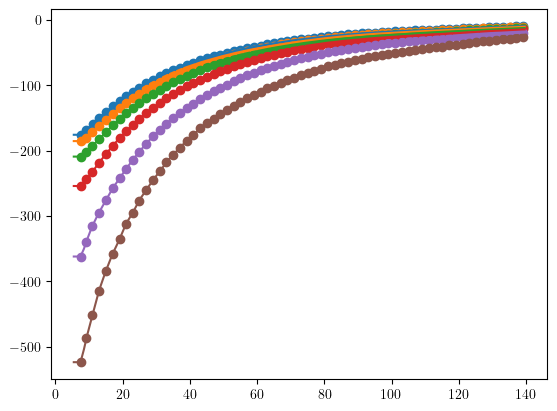

In [20]:
M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

for k in range(len(M_cens)):
    r, mu, sd, N = vr_profile(h, k) 

    plt.scatter(r, mu)
    plt.plot(r_p, interps[k](r_p))

In [26]:
ST_pars_check.shape

(135, 135, 3)

[84.47324609  0.69635291]


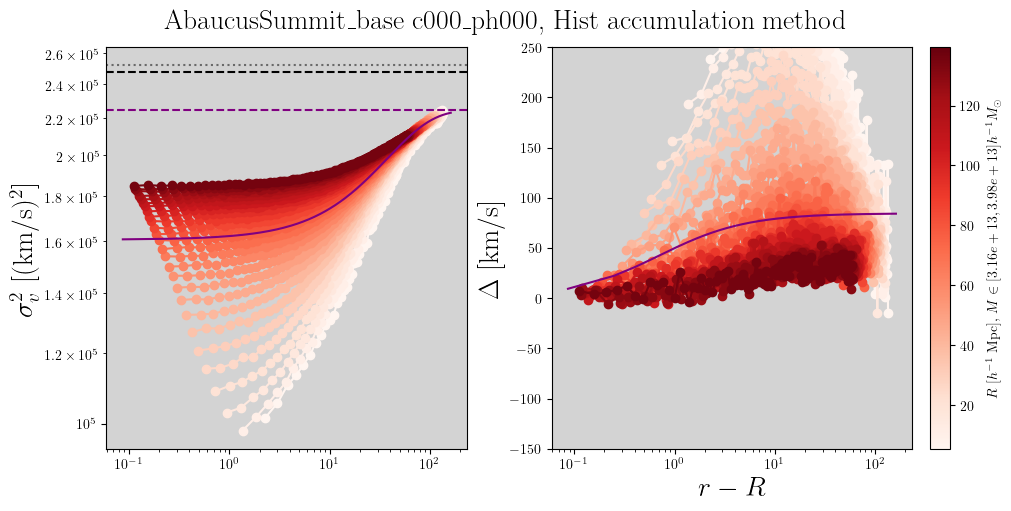

In [48]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


skip = 5


A_rho_R = np.full((len(r_p)//skip), np.nan)
A_rho_R_err = np.full(A_rho_R.shape, np.nan)


sig_rho_fix = sig_opts[-1]


fig, ax = plt.subplots(1, 2, figsize=(10, 5*1), layout='constrained', sharex=True)

fig.suptitle(rf"AbaucusSummit_base c000_ph000, Hist accumulation method", fontsize=20)

for k in range(1):

    k = 3

    mean_vr_interp = interps[k]

    Delta = ST_pars_check[:, :, 0] - mean_vr_interp(r) * r_l / r
    com_inputs = [(meas_sigv_check)**2, Delta]

    smask = np.isfinite((meas_sigv_check).flatten()) #& ((meas_sigv_check).flatten() > 0.1)
    dmask = np.isfinite(Delta.flatten()) #& (Delta.flatten() > -1000)

    # fit models to each input 

    popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], ((meas_sigv_check)).flatten()[smask], p0=[sigma, 0.3, 10], maxfev=5_000, absolute_sigma=False)
    popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

    sig_opts = popt_sig
    sig_errs = np.sqrt(np.diag(sig_cov))
    del_opts = popt_del 
    del_errs = np.sqrt(np.diag(del_cov))


    xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

    for j in range(0, len(r_p), skip):
        for i in range(2):

            y = com_inputs[i][j, :]
            
            if i == 0:
                mask = y > 0.1

                # if j == 0:
                #     popt, pcov = curve_fit(lambda x, A, s: sigma_mod(x, sig_opts[k, 0], A, s), x2[:, j], meas_sigv_check[k, j, :], p0=popt_sig[1:], maxfev=5_000, absolute_sigma=True)
                #     A_rho_R[k, j//skip], sig_rho_fix = popt
                #     A_rho_R_err[k, j//skip] = np.sqrt(pcov[0, 0])

                #     ax[i].plot(xs, sigma_mod(xs, sig_opts[k, 0], *popt )**2, c=cmaps[k][j], ls='--')

                # else:
                #     popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[k, 0], A, sig_rho_fix), x2[:, j], meas_sigv_check[k, j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)

                #     A_rho_R[k, j//skip] = popt
                #     A_rho_R_err[k, j//skip] = np.sqrt(pcov)

                #     ax[i].plot(xs, sigma_mod(xs, sig_opts[k, 0], popt, sig_rho_fix )**2, c=cmaps[k][j], ls='--')

            if i == 1:
                mask = y > -1000

            ax[i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[3][j])

            ax[i].set_facecolor('lightgray')
            
            ax[i].set_ylabel(names[i], fontsize=20)
            
            ax[i].set_xscale('log')
            
    norm = Normalize(vmin=min(r_p), vmax=max(r_p))
    sm = ScalarMappable(norm=norm, cmap=colormap_list[3])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax[-1])
    cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc], $M\in[{massbins[3, 0]:.2e}, {massbins[3, 1]:.2e}] h^{{-1}} M_\odot $", fontsize=10)

    ax[0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
    #ax[0].set_ylim((140_000, 300_000))
    ax[0].set_xscale('log')
    ax[0].axhline(2*(sigma)**2, c='k', ls='--')
    ax[0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
    ax[0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
    ax[0].set_yscale('log')

    #ax[0].set_xlabel(r'$r-R$', fontsize=20)
    ax[1].set_xlabel(r'$r-R$', fontsize=20)

    ax[1].plot(xs, delta_mod(xs, *popt_del), c='purple')
    print(popt_del)
    ax[1].set_ylim((-150, 250))

In [49]:
popt_sig

array([3.34999538e+02, 2.83776700e-01, 4.23279876e+01])

In [ ]:
[52.92169338  0.78023249]